In [4]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

#Restricts the timesteps of the data from timesteps0 to 140
data=data.isel(time=np.arange(1,140+1))
parcel=parcel.isel(time=np.arange(1,140+1))

def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh
    
def grid_location(x,y,z): #faster
    #finding xf and yf
    ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
    xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
    dy=np.round(dy);dx=np.round(dx)

    #digitizing
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
    if which_zh.ndim==0:
        which_zh=np.array([which_zh])
    which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
    which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

    #fixing boundaries
    which_zh[np.where(which_zh==len(data['zh']))]-=1
    which_yh[np.where(which_yh==len(data['yh']))]-=1
    which_xh[np.where(which_xh==len(data['xh']))]-=1
    return which_zh,which_yh,which_xh
    
x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)


which_t = np.ndarray((which_z.shape[0], which_z.shape[1]))
for i in range(which_z.shape[0]):
    which_t[i, :] = i
which_t=which_t.copy().astype(int)

In [ ]:
#######################################################################################################################################
#Calling Data and Plotting Next

In [30]:
# #Job Array

# num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***

# job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
# if job_id==0: job_id=1
# num_parcels=len(data['time']) #total number of parcels
# job_range = num_parcels//num_jobs #number of parcels per job 

# # Calculate start and end based on job_id
# start_job = (job_id - 1) * job_range
# end_job = start_job + job_range
# if job_id==num_jobs: end_job=num_parcels-1
# print(f'running for parcels {start_job}-{end_job-1}')

# data=data.isel(time=slice(start_job,end_job))
# parcel=parcel.isel(time=slice(start_job,end_job))

# x=parcel['x'];y=parcel['y'];z=parcel['z']
# which_z,which_y,which_x=grid_location(x,y,z)

# which_t = np.ndarray((which_z.shape[0], which_z.shape[1]))
# for i in range(which_z.shape[0]):
#     which_t[i, :] = i
# which_t=which_t.copy().astype(int)

In [15]:
#All Parcels Lagrangian Parcels Profile (OPTIMIZED)

if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data

    import h5py
    with h5py.File(dir + 'theta_e.h5', 'r') as f:
        theta_e_data = f['theta_e'][:]
        
    print('done loading')
    emptylike=True


types=['general','cloudy']
vars=['w','qv','qc','qi','th','buoyancy']
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    global w_thresh
    w_thresh=1; w_thresh=0.5 #m/s
    qcqi_thresh=1e-6; qcqi_thresh=1e-9 #kg/kg
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        if var=='qv':
            lagrangian_var=qv_data[position]
        if var=='qc':
            lagrangian_var=qc_plus_qi[position] #data stored for qc is actually qc+qi
        if var=='qi':
            lagrangian_var=qi_data[position]
        if var=='th':
            # lagrangian_var=th_data[position]
            lagrangian_var=theta_e_data[position]
        if var=='buoyancy':
            lagrangian_var=buoyancy_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='general':
            masked_var=lagrangian_var[np.where(lagrangian_w>=w_thresh)]
            masked_z=which_z.flatten()[np.where(lagrangian_w>=w_thresh)]
        elif type=='cloudy':
            masked_var=lagrangian_var[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
            masked_z=which_z.flatten()[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='general':
        output_file=dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{w_thresh}.h5'
    if type=='cloudy':
        output_file=dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
        f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
    print('done')

type general
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done
type cloudy
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done


In [1]:
# #All Parcels Lagrangian Parcels Profile (OPTIMIZED) (CTRL)

# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data
#     variable='th'; th_data=data[variable].data # get qc data
#     variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
#     print('done loading')
#     emptylike=True


# types=['general','cloudy']
# vars=['w','qv','qc','qi','th','buoyancy']
# for type in types:
#     print(f"type {type}")

#     global w_thresh
#     # #creates profile storage and adds z column  
#     w_thresh=1 #m/s
#     qcqi_thresh=1e-6 #kg/kg
    
#     #create profile array
#     for var in vars:
#         zhs=data['zh'].values
#         globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#         globals()[f"profile_{var}"][:,2]=zhs

#     position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
#     lagrangian_w=w_data[position]
#     lagrangian_qcplusqi=qc_plus_qi[position]
    
#     for var in vars:
#         print(f"variable {var}")
#         if var=='w':
#             lagrangian_var=w_data[position]
#         if var=='qv':
#             lagrangian_var=qv_data[position]
#         if var=='qc':
#             lagrangian_var=qc_plus_qi[position] #data stored for qc is actually qc+qi
#         if var=='qi':
#             lagrangian_var=qi_data[position]
#         if var=='th':
#             lagrangian_var=th_data[position]
#         if var=='buoyancy':
#             lagrangian_var=buoyancy_data[position]

              
#         #if w_zdata greater than threshold, add to profile z column and add count
#         if type=='general':
#             masked_var=lagrangian_var[np.where(lagrangian_w<w_thresh)]
#             masked_z=which_z.flatten()[np.where(lagrangian_w<w_thresh)]
#         elif type=='cloudy':
#             masked_var=lagrangian_var[np.where((lagrangian_w<w_thresh)|(lagrangian_qcplusqi<qcqi_thresh))]
#             masked_z=which_z.flatten()[np.where((lagrangian_w<w_thresh)|(lagrangian_qcplusqi<qcqi_thresh))]
            
#         for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
#             # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
#             globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
#             globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
#     if type=='general':
#         output_file=dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5'
#     if type=='cloudy':
#         output_file=dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5'
#     import h5py
#     with h5py.File(output_file, 'w') as f:
#         f.create_dataset('profile_w', data=profile_w, compression="gzip")
#         f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
#         f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
#         f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
#         f.create_dataset('profile_th', data=profile_th, compression="gzip")
#         f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
#     print('done')

In [ ]:
##################
# Plotting

currently on type general
currently on type cloudy


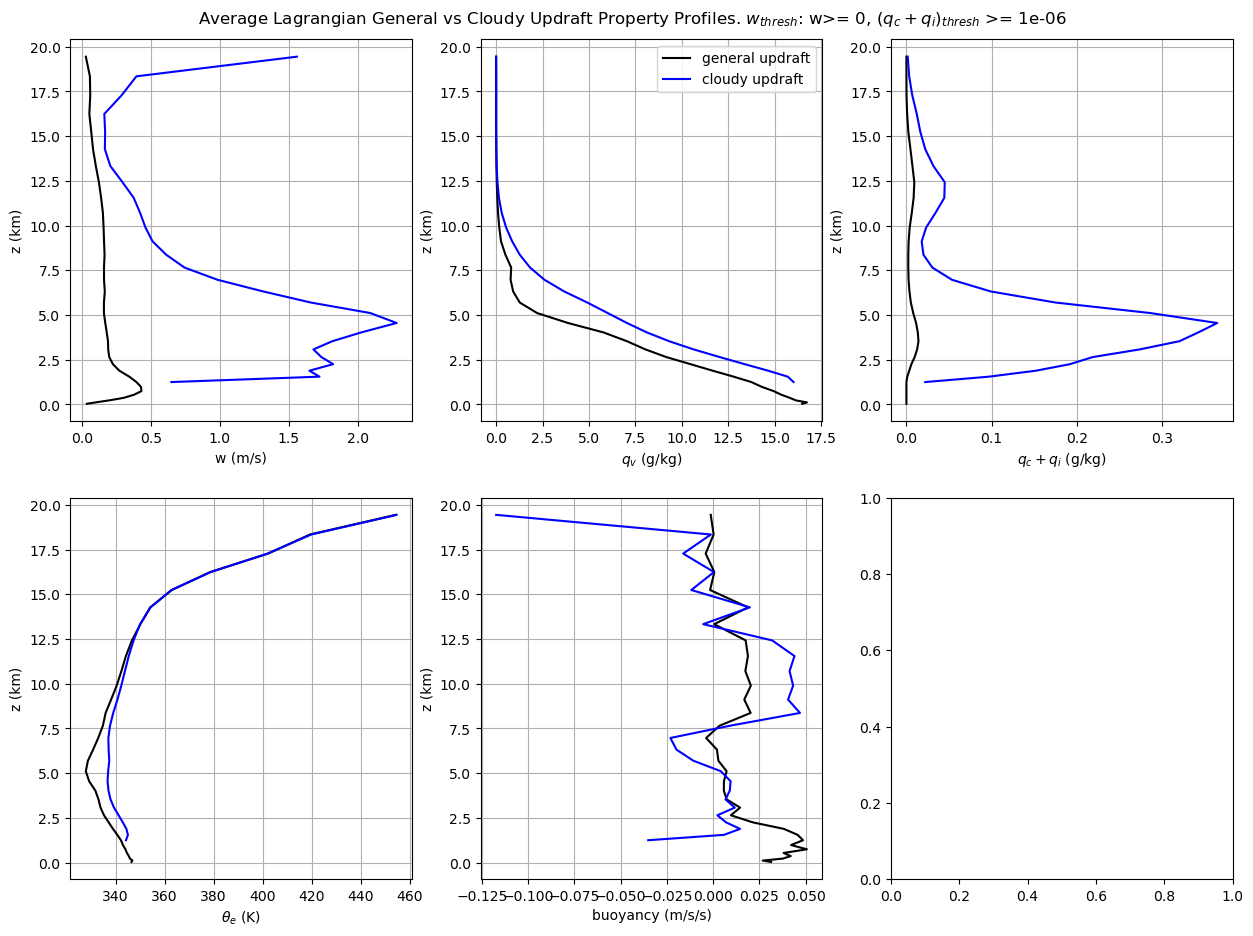

In [16]:
#Plotting (for all variables)
import h5py

# Produced averaged profiles for plotting
def averaged_profiles(var):
    profile = globals()[f"profile_{var}"]
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

####################################################################
dim = '1km'
# dim = '250m'
w_thresh=0; #w_thresh=0.5 #m/s
qcqi_thresh=1e-6; #qcqi_thresh=1e-9 #kg/kg

# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average Lagrangian General vs Cloudy Updraft Property Profiles. " + r"$w_{thresh}$: w>= " + f"{w_thresh}, " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
fig.subplots_adjust(top=0.95)
####################################################################
for type in ["general", "cloudy"]:
    print(f'currently on type {type}')

    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5' 
    
    if dim=='250m':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_lagrangian_profiles_wthresh{w_thresh}.h5' 
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_buoyancy = np.array(f['profile_buoyancy'])
            
    #adding qc and qi profile together
    profile_qc[:,0]+=profile_qi[:,0] 
    profile_qc[:,1]+=profile_qi[:,1] 

    for var in ['qv','qc']:
        globals()[f"profile_{var}"][:,0]*=1000
    
    # Plotting function
    def plotting(out_var, axis, label, color):
        axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color)
        axis.grid(True)
    
    # Uses Averaged_Profiles Function
    vars = ['w', 'qv', 'qc', 'th','buoyancy']
    # vars = ['w']  # TESTING
    for var in vars:
        globals()[f"out_{var}"] = averaged_profiles(var)
    
    axises = [ax1, ax2, ax3, ax4, ax5]
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for var, axis, xlabel in zip(vars, axises, xlabels):
        if type == 'general':
            color = 'k'
        elif type == 'cloudy':
            color = 'blue'
        plotting(globals()[f"out_{var}"], axis, label=type + ' updraft', color=color)
        axis.set_ylabel('z (km)')
        axis.set_xlabel(xlabel)
        if axis==ax2:
            axis.legend()  # add legend
############################

#save plot
if dim == '1km':
    plt.savefig(dir+f'tracking_algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"
elif dim == '250m':
    plt.savefig(dir+f'tracking_algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"


In [82]:
# #CTRL Plotting (for all variables)
# import h5py

# # Produced averaged profiles for plotting
# def averaged_profiles(var):
#     profile = globals()[f"profile_{var}"]
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# ####################################################################
# dim = '1km'
# # dim = '250m'

# # Uses Plotting Function 
# fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# fig.suptitle(f"Average Lagrangian Non-General vs Non-Cloudy Updraft CTRL Property Profiles")
# ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
# fig.subplots_adjust(top=0.95)
# ####################################################################
# for type in ["general", "cloudy"]:
#     print(f'currently on type {type}')

#     if dim=='1km':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5' 
    
#     if dim=='250m':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5' 
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5' 
    
#     with h5py.File(input_file, 'r') as f:
#         profile_w = np.array(f['profile_w'])
#         profile_qv = np.array(f['profile_qv'])
#         profile_qc = np.array(f['profile_qc'])
#         profile_qi = np.array(f['profile_qi'])
#         profile_th = np.array(f['profile_th'])
#         profile_buoyancy = np.array(f['profile_buoyancy'])
            
#     #adding qc and qi profile together
#     profile_qc[:,0]+=profile_qi[:,0] 
#     profile_qc[:,1]+=profile_qi[:,1] 

#     for var in ['qv','qc']:
#         globals()[f"profile_{var}"][:,0]*=1000
    
#     # Plotting function
#     def plotting(out_var, axis, label, color):
#         axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color)
#         axis.grid(True)
    
#     # Uses Averaged_Profiles Function
#     vars = ['w', 'qv', 'qc', 'th','buoyancy']
#     # vars = ['w']  # TESTING
#     for var in vars:
#         globals()[f"out_{var}"] = averaged_profiles(var)
    
#     axises = [ax1, ax2, ax3, ax4, ax5]
#     xlabels = ['w (m/s)', 'qv (g/kg)', 'qc + qi (g/kg)', 'th (K)', 'buoyancy (m/s/s)']
#     for var, axis, xlabel in zip(vars, axises, xlabels):
#         if type == 'general':
#             color = 'k'
#         elif type == 'cloudy':
#             color = 'blue'
#         plotting(globals()[f"out_{var}"], axis, label=type + ' updraft', color=color)
#         axis.set_ylabel('z (km)')
#         axis.set_xlabel(xlabel)
#         if axis==ax2:
#             axis.legend()  # add legend
# ############################

# #save plot
# if dim == '1km':
#     plt.savefig(dir+f'tracking_algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"
# elif dim == '250m':
#     plt.savefig(dir+f'tracking_algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"


currently on type general
currently on type cloudy


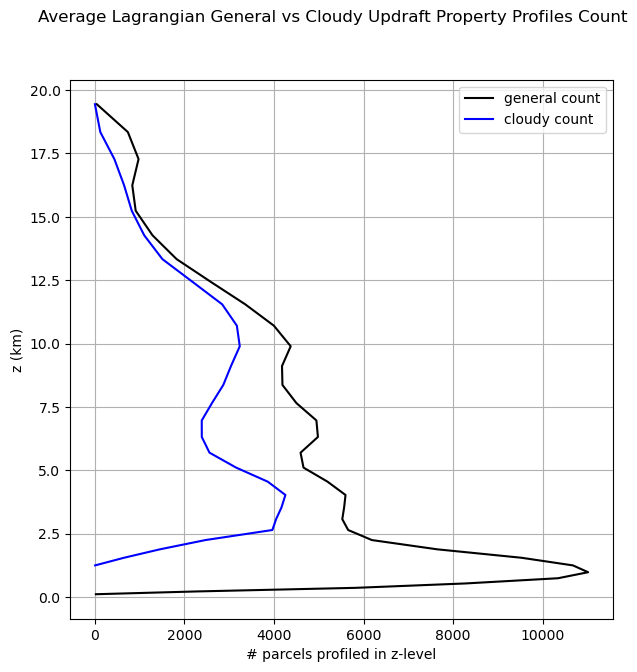

In [13]:
#Plotting counter column
dim='1km'
# dim='250m'

#Uses CounterPlotting Function
fig, axs = plt.subplots(1,1, figsize=(7,7))
fig.suptitle(f"Average Lagrangian General vs Cloudy Updraft Property Profiles Count")
# fig.suptitle(f"average lagrangian cloudy updraft property profiles") #uncomment if "cloudy updrafts"
# ax1 = axs.flatten()
# plt.tight_layout()
types=["general","cloudy"]
for type in types:
    print(f'currently on type {type}')

    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5' 
    
    if dim=='250m':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_general_lagrangian_profiles_wthresh{w_thresh}.h5' 
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5' 
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_buoyancy = np.array(f['profile_buoyancy'])



    def counter_plotting(out_var,axis,label,color):
        out_var=out_var[ (out_var[:, 1] != 0)];
        axis.plot(out_var[:,1],out_var[:,2],label=label,color=color)
        axis.grid(True)

        # print(np.sum(out_var[:,1])) #TESTING
    
    vars=['w']
    axises=[axs]
    xlabels=['# parcels profiled in z-level']
    for var,axis,xlabel in zip(vars,axises,xlabels):
        if type=='general':
            color='k'
        elif type=='cloudy':
            color='blue'
        counter_plotting(globals()[f"profile_{var}"],axis,label=type+' count',color=color)
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.legend();
    ############################# 
    #save plot
    dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    if dim=='1km':
        plt.savefig(dir+f'tracking_algorithms/plots/1km_lagrangian_generalvscloudy_updraft_profile_counter_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 
    if dim=='250m':
        plt.savefig(dir+f'tracking_algorithms/plots/250m_lagrangian_generalvscloudy_updraft_profile_counter_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) 

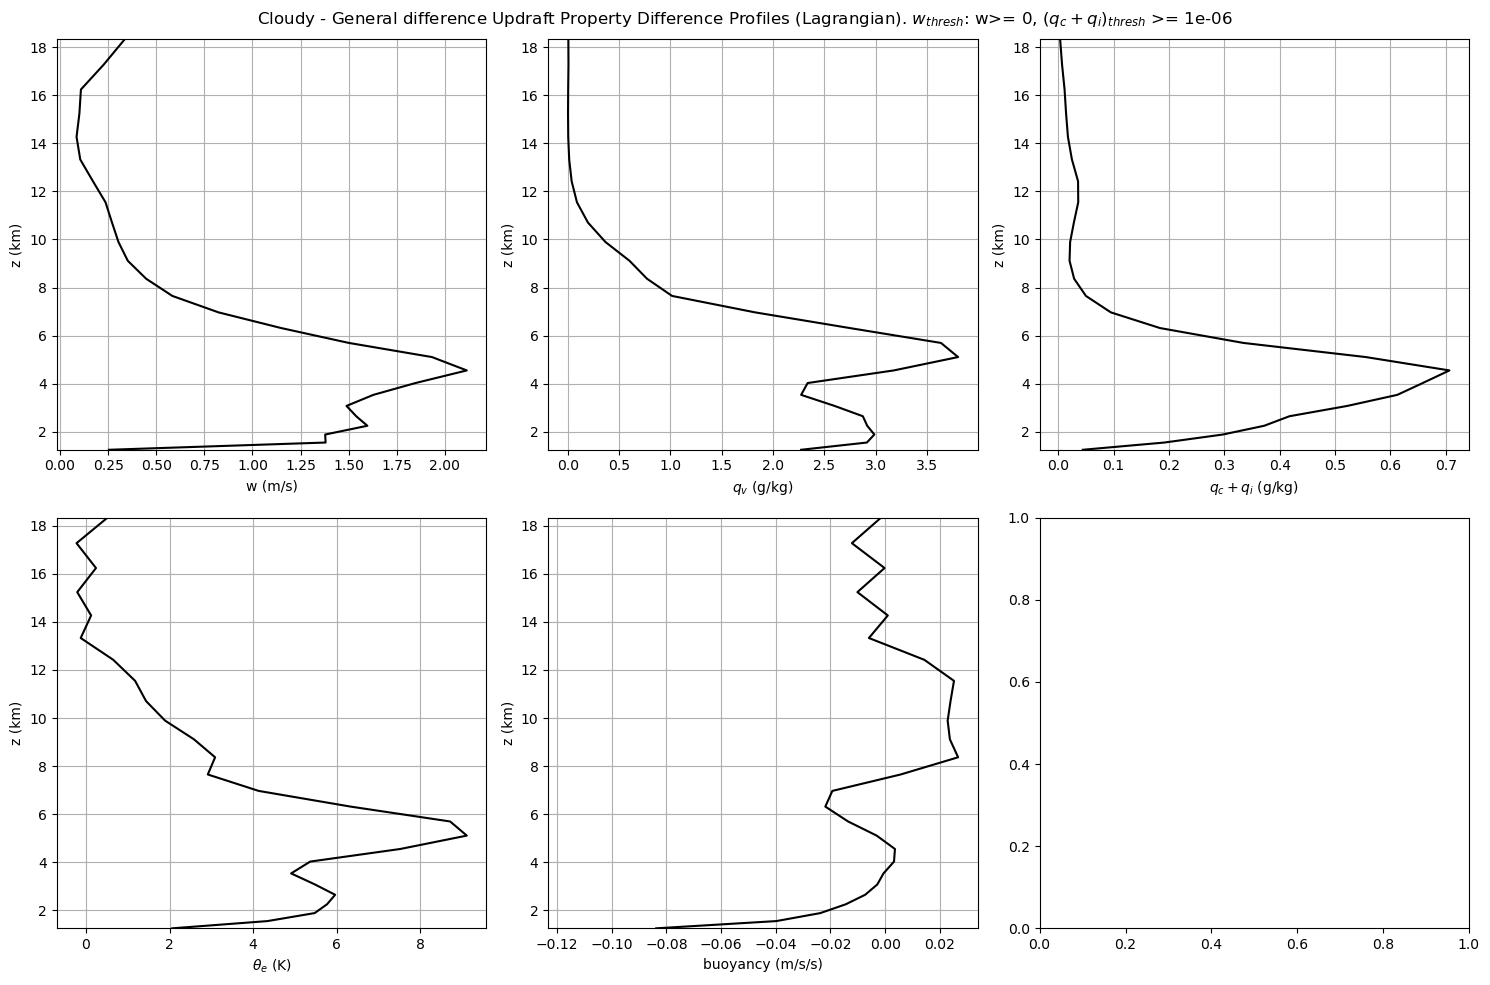

In [17]:
#Plotting Differences
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

dim='1km'
def get_data(type):
    if dim=='1km':
        if type=='general':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_wthresh{w_thresh}.h5'
        elif type=='cloudy':
            input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_wthresh{w_thresh}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
        globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])

    
def diff_plotting():
    #setting up figure
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Cloudy - General difference Updraft Property Difference Profiles (Lagrangian). " + r"$w_{thresh}$: w>= " + f"{w_thresh}, " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}")
    ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

    #the plotting
    vars=['w','qv','qc','th','buoyancy']
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta_e$ (K)','buoyancy (m/s/s)'] #qi (g/kg)
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        if var=='qv':axis=ax2
        if var=='qc':axis=ax3
        if var=='th':axis=ax4
        if var=='buoyancy':axis=ax5

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        cutofflow=np.where(out_var_one[:,1]>10)[0][0]
        cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
  
        out_var_one=averaged_profiles(out_var_one.copy())
        out_var_two=averaged_profiles(out_var_two.copy())

        #masking out non matches
        second_col_one = out_var_one[:, 1]
        second_col_two = out_var_two[:, 1]
        mask_one = np.isin(second_col_one, second_col_two)
        mask_two = np.isin(second_col_two, second_col_one)
        out_var_one = out_var_one.copy()[mask_one]
        out_var_two = out_var_two.copy()[mask_two]

        #converting kg/kg to g/kg
        if var=='qv' or var=='qc':
            out_var_one[:,0]*=1000
            out_var_two[:,0]*=1000
        
        axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],color='k')
        # axis.set_ylim(bottom=0,top=20)
        axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable

        # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
        
    plt.tight_layout()
    plt.savefig(dir+f'tracking_algorithms/plots/1km_lagrangian_updraft_profiles_diff_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) #save plot
diff_plotting() 

In [87]:
# #CTRL Plotting Differences
# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# dim='1km'
# def get_data(type):
#     if dim=='1km':
#         if type=='general':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5'
#         elif type=='cloudy':
#             input_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_CTRL_wthresh{w_thresh}.h5'
    
#     with h5py.File(input_file, 'r') as f:
#         globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
#         globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
#         globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
#         globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
#         globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
#         globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])

    
# def CTRL_diff_plotting():
#     #setting up figure
#     fig, axs = plt.subplots(2, 3, figsize=(15, 10))
#     fig.suptitle(f"Non-Cloudy - Non-General Difference Updraft CTRL Property Difference Profiles (Lagrangian)")
#     ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

#     #the plotting
#     vars=['w','qv','qc','th','buoyancy']
#     xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
#     for xlabel,var in zip(xlabels,vars):
        
#         if var=='w':axis=ax1
#         if var=='qv':axis=ax2
#         if var=='qc':axis=ax3
#         if var=='th':axis=ax4
#         if var=='buoyancy':axis=ax5

#         #get profile
#         types=['cloudy','general']
#         get_data(types[0])
#         out_var_one=globals()[f"{types[0]}_profile_{var}"]
#         get_data(types[1])
#         out_var_two=globals()[f"{types[1]}_profile_{var}"]

#         #finding where cloudy updraft count goes below 10
#         cutofflow=np.where(out_var_one[:,1]>10)[0][0]
#         cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
  
#         out_var_one=averaged_profiles(out_var_one.copy())
#         out_var_two=averaged_profiles(out_var_two.copy())

#         #masking out non matches
#         second_col_one = out_var_one[:, 1]
#         second_col_two = out_var_two[:, 1]
#         mask_one = np.isin(second_col_one, second_col_two)
#         mask_two = np.isin(second_col_two, second_col_one)
#         out_var_one = out_var_one.copy()[mask_one]
#         out_var_two = out_var_two.copy()[mask_two]

#         #converting kg/kg to g/kg
#         if var=='qv' or var=='qc':
#             out_var_one[:,0]*=1000
#             out_var_two[:,0]*=1000
        
#         axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],color='k')
#         # axis.set_ylim(bottom=0,top=20)
#         axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
#         #labeling
#         axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
#         axis.grid(True)
#         # axis.legend(fontsize='small') #only adds legend at final variable

#         # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
        
#     plt.tight_layout()
#     plt.savefig(dir+f'tracking_algorithms/plots/1km_lagrangian_updraft_profiles_diff_CTRL_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) #save plot
# CTRL_diff_plotting() 

In [ ]:
#######################################################################################################################################
#Lagrangian Tracking for Tracked Deep Convective Parcels

In [10]:
#Deep Convective Parcels Profile
##### viewing tracking algorithm results
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import h5py

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [3]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 

###############################################################################
out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
####################################################
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def threshold(zthresh):
    out_nz=placeholder.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh):
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz, extendrange
    # print(out_nz)
##############################################################

convectivelevel=6 #6km
[out_nz,extendrange]=threshold(convectivelevel)

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} non-SBZ parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
list of first 10 SBZ parcels
[[452 334 53 0.1520338897705078 43 48]
 [704 374 63 0.24067965698242189 57 62]
 [885 300 10 0.11673685455322266 59 65]
 [1022 37

In [12]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh
    
# def grid_location(x,y,z): #faster
#     #finding xf and yf
#     ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
#     xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
#     dy=np.round(dy);dx=np.round(dx)

#     #digitizing
#     zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
#     if which_zh.ndim==0:
#         which_zh=np.array([which_zh])
#     which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
#     which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

#     #fixing boundaries
#     which_zh[np.where(which_zh==len(data['zh']))]-=1
#     which_yh[np.where(which_yh==len(data['yh']))]-=1
#     which_xh[np.where(which_xh==len(data['xh']))]-=1
#     return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for deep parcel locations
######################################################

#Setting up run for deep convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


deep_t,deep_z,deep_y,deep_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    deep_t.extend(ranges[R])
    deep_z.extend(which_z[tup])
    deep_y.extend(which_y[tup])
    deep_x.extend(which_x[tup])
deep_t=np.array(deep_t);deep_z=np.array(deep_z);deep_y=np.array(deep_y);deep_x=np.array(deep_x)
position=(deep_t, deep_z, deep_y, deep_x)
print('done')

running for total of 3118 elements
done


In [13]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    print('done loading')
    emptylike=True


types=['general','cloudy','all']
vars=['w','qv','qc','qi','th','buoyancy']
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    global w_thresh
    w_thresh=1 #m/s
    qcqi_thresh=1e-6 #kg/kg
    all_thresh=-1e6
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        if var=='qv':
            lagrangian_var=qv_data[position]
        if var=='qc':
            lagrangian_var=qc_plus_qi[position] #data stored for qc is actually qc+qi
        if var=='qi':
            lagrangian_var=qi_data[position]
        if var=='th':
            lagrangian_var=th_data[position]
        if var=='buoyancy':
            lagrangian_var=buoyancy_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='general':
            masked_var=lagrangian_var[np.where(lagrangian_w>=w_thresh)]
            masked_z=deep_z.flatten()[np.where(lagrangian_w>=w_thresh)]
        elif type=='cloudy':
            masked_var=lagrangian_var[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
            masked_z=deep_z.flatten()[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
        elif type=='all':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=deep_z.flatten()[np.where(lagrangian_w>=all_thresh)]
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='all':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
    if type=='general':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
    if type=='cloudy':
        output_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
        f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
    print('done')

type general
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done
type cloudy
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done
type all
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done


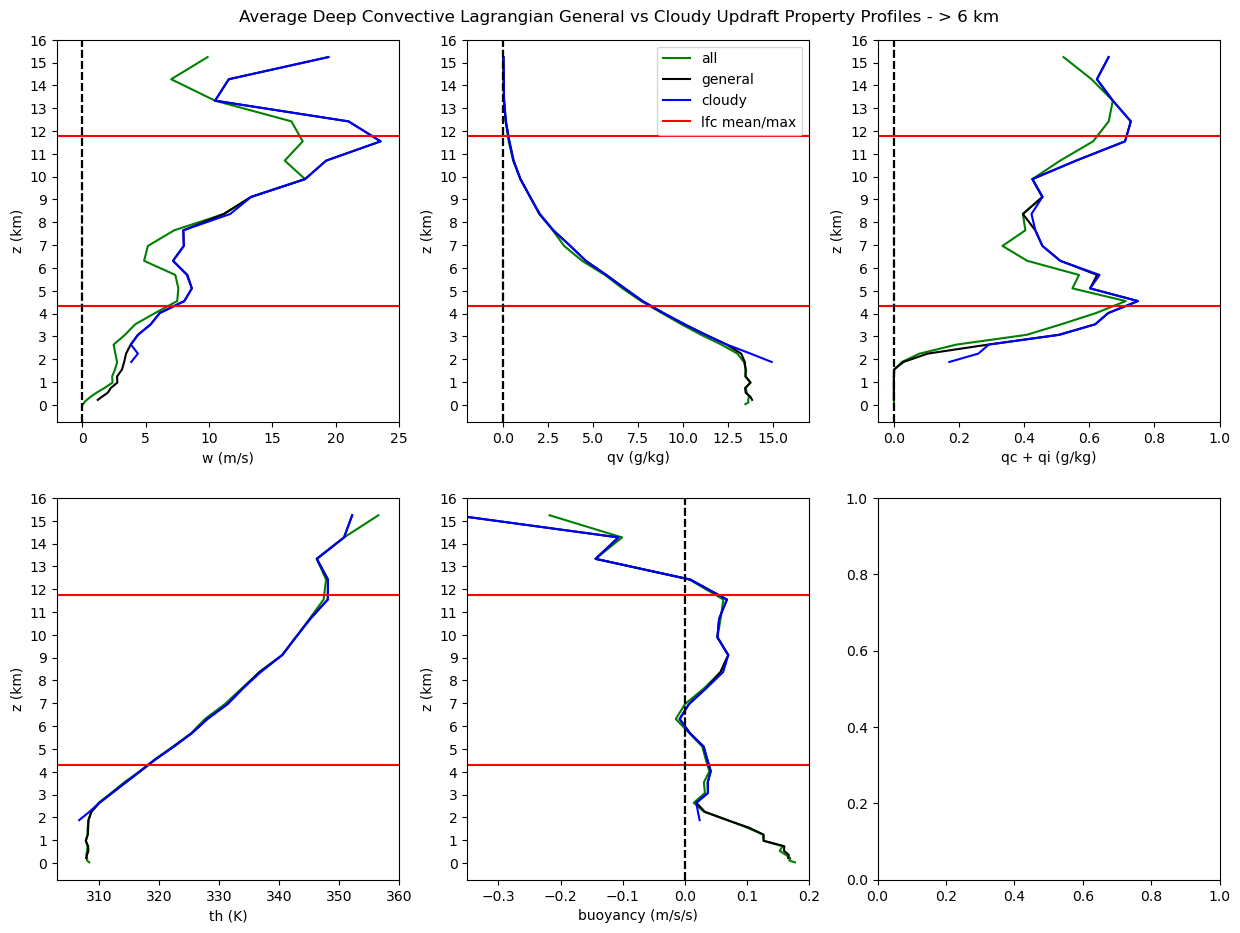

In [25]:
#Plotting for deep tracked parcels 

w_thresh=1
convectivelevel=6

#last tracked time
zs=[]
for R in np.arange(len(out_nz)):
    z=parcel['z'].isel(xh=out_nz[:,0][R],time=out_nz[:,5][R]).values/1000
    zs.append(z)
avg_lfc=np.mean(zs)
max_lfc=np.max(zs)


# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average Deep Convective Lagrangian General vs Cloudy Updraft Property Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
axises=[ax1,ax2,ax3,ax4,ax5,ax6]
fig.subplots_adjust(top=0.95)


#lfc
lfc_tmean=data['lfc'].mean(dim='time')/1000


vars=['w','qv','qc','th','buoyancy']
xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
for var,xlabel,axis in zip(vars,xlabels,axises):
    types=['all','general','cloudy']
    labels=['all','general','cloudy']
    colors=['green','k','blue']
    for type,label,color in zip(types,labels,colors):
        if type=='all':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
        if type=='general':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
        if type=='cloudy':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
        with h5py.File(input_file, 'r') as f:
            profile_w = np.array(f['profile_w'])
            profile_qv = np.array(f['profile_qv'])
            profile_qc = np.array(f['profile_qc'])
            profile_qi = np.array(f['profile_qi'])
            profile_th = np.array(f['profile_th'])
            profile_buoyancy = np.array(f['profile_buoyancy'])
        
         #globalize output
        globals()['profile_w'] = profile_w
        globals()['profile_qv'] = profile_qv
        globals()['profile_qc'] = profile_qc
        globals()['profile_qi'] = profile_qi
        globals()['profile_th'] = profile_th
        globals()['profile_buoyancy'] = profile_buoyancy

        #adding qc and qi profile together
        profile_qc[:,0]+=profile_qi[:,0] 
        profile_qc[:,1]+=profile_qi[:,1] 

        #converting kg/kg to g/kg
        profile_qv[:,0]*=1000
        profile_qc[:,0]*=1000
        
        #Produced averaged profiles for plotting
        def averaged_profiles(profile): 
            out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
            out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
            return out_var
        
        profile=averaged_profiles(globals()[f'profile_{var}'])
        yticks = np.arange(0, profile[:,1].max()+1, 1)
        axis.set_yticks(yticks)
    
        axis.plot(profile[:,0],profile[:,1],label=label,color=color)
        axis.set_xlabel(xlabel);axis.set_ylabel('z (km)')

        if axis==ax1:
            axis.set_xlim(-2,25)
        if axis==ax2:
            axis.set_xlim(-2,17)
        if axis==ax3:
            axis.set_xlim(-0.05,1)
        if axis==ax4:
            axis.set_xlim(303,360)
        if axis==ax5:
            axis.set_xlim(-0.35,0.2)      


        if type=='cloudy':
            axis.axhline(avg_lfc,color='red',linestyle='solid')
            axis.axhline(max_lfc,color='red',linestyle='solid',label='lfc mean/max')
        if var!='th':
            axis.axvline(0,linestyle='dashed',color='k')
        if axis==ax2:
            axis.legend(loc='upper right');

#saving figure
fig.savefig(dir+f'tracking_algorithms/plots/deep_profiles_{convectivelevel}km_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"

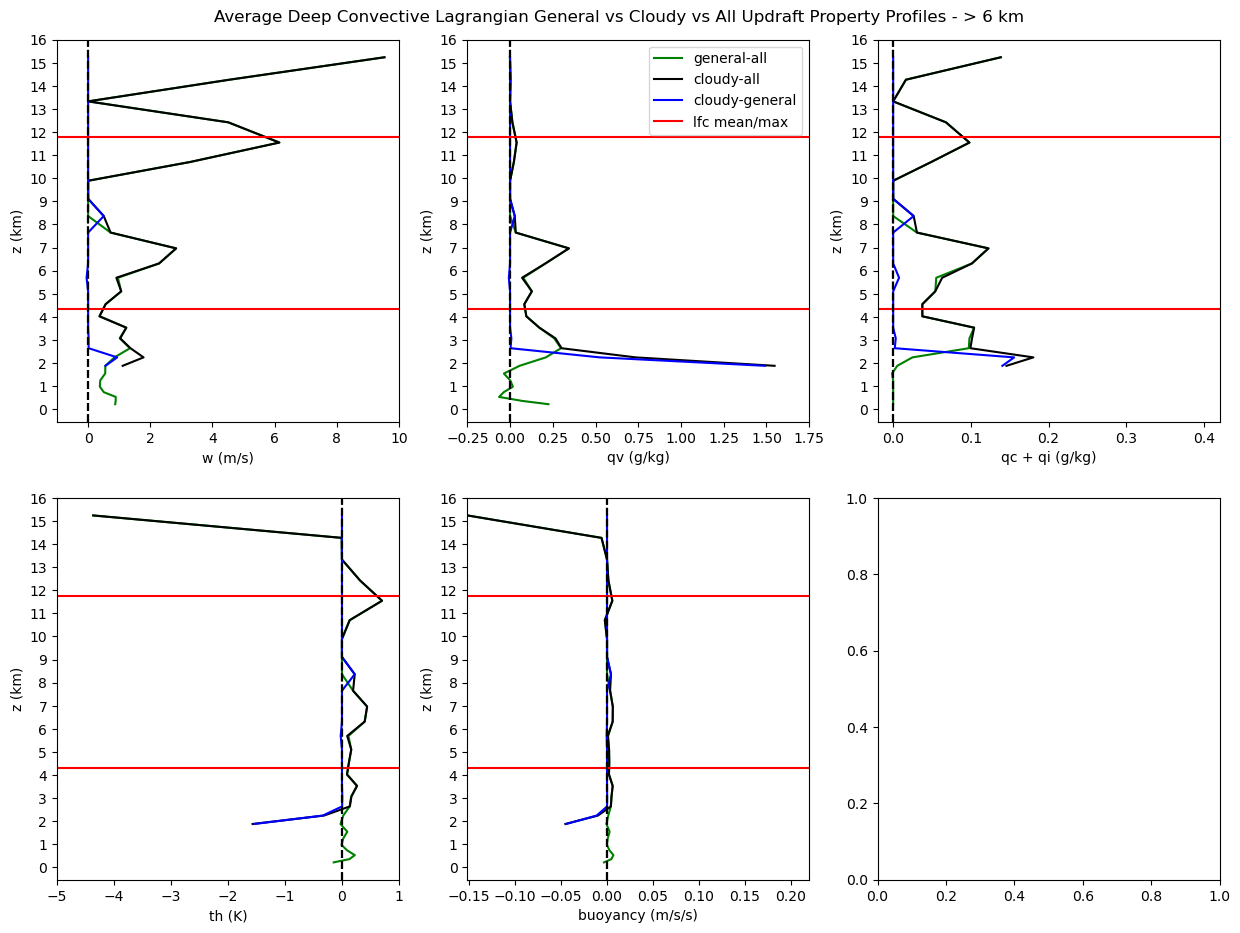

In [37]:
#DIFFERENCE PLOT
#general - all
#cloudy - all 
#cloudy - general

#use for tracked parcels

w_thresh=1
convectivelevel=6

#last tracked time
zs=[]
for R in np.arange(len(out_nz)):
    z=parcel['z'].isel(xh=out_nz[:,0][R],time=out_nz[:,5][R]).values/1000
    zs.append(z)
avg_lfc=np.mean(zs)
max_lfc=np.max(zs)


# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average Deep Convective Lagrangian General vs Cloudy vs All Updraft Property Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
axises=[ax1,ax2,ax3,ax4,ax5,ax6]
fig.subplots_adjust(top=0.95)


#lfc
lfc_tmean=data['lfc'].mean(dim='time')/1000

#Produced averaged profiles for plotting
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

vars=['w','qv','qc','th','buoyancy']
xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
for var,xlabel,axis in zip(vars,xlabels,axises):
    types=['general-all','cloudy-all','cloudy-general']
    labels=['general-all','cloudy-all','cloudy-general']
    colors=['green','k','blue']
    for type,label,color in zip(types,labels,colors):
        if type=='general-all':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])



            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 
            #globalize output
            globals()['one_profile_w'] = profile_w
            globals()['one_profile_qv'] = profile_qv
            globals()['one_profile_qc'] = profile_qc
            globals()['one_profile_qi'] = profile_qi
            globals()['one_profile_th'] = profile_th
            globals()['one_profile_buoyancy'] = profile_buoyancy
                

            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
                
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 
            #globalize output
            globals()['two_profile_w'] = profile_w
            globals()['two_profile_qv'] = profile_qv
            globals()['two_profile_qc'] = profile_qc
            globals()['two_profile_qi'] = profile_qi
            globals()['two_profile_th'] = profile_th
            globals()['two_profile_buoyancy'] = profile_buoyancy

            #averaging
            out_var_one=averaged_profiles(globals()[f'one_profile_{var}'])
            out_var_two=averaged_profiles(globals()[f'two_profile_{var}'])
    
            #masking out non matches
            second_col_one = out_var_one[:, 1]
            second_col_two = out_var_two[:, 1]
            mask_one = np.isin(second_col_one, second_col_two)
            mask_two = np.isin(second_col_two, second_col_one)
            out_var_one = out_var_one.copy()[mask_one]
            out_var_two = out_var_two.copy()[mask_two]

        if type=='cloudy-all':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 

            #globalize output
            globals()['one_profile_w'] = profile_w
            globals()['one_profile_qv'] = profile_qv
            globals()['one_profile_qc'] = profile_qc
            globals()['one_profile_qi'] = profile_qi
            globals()['one_profile_th'] = profile_th
            globals()['one_profile_buoyancy'] = profile_buoyancy

            
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 

            #globalize output
            globals()['two_profile_w'] = profile_w
            globals()['two_profile_qv'] = profile_qv
            globals()['two_profile_qc'] = profile_qc
            globals()['two_profile_qi'] = profile_qi
            globals()['two_profile_th'] = profile_th
            globals()['two_profile_buoyancy'] = profile_buoyancy

            #averaging
            out_var_one=averaged_profiles(globals()[f'one_profile_{var}'])
            out_var_two=averaged_profiles(globals()[f'two_profile_{var}'])
    
            #masking out non matches
            second_col_one = out_var_one[:, 1]
            second_col_two = out_var_two[:, 1]
            mask_one = np.isin(second_col_one, second_col_two)
            mask_two = np.isin(second_col_two, second_col_one)
            out_var_one = out_var_one.copy()[mask_one]
            out_var_two = out_var_two.copy()[mask_two]
        
        if type=='cloudy-general':
            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 

            #globalize output
            globals()['one_profile_w'] = profile_w
            globals()['one_profile_qv'] = profile_qv
            globals()['one_profile_qc'] = profile_qc
            globals()['one_profile_qi'] = profile_qi
            globals()['one_profile_th'] = profile_th
            globals()['one_profile_buoyancy'] = profile_buoyancy

            input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 
        
            #globalize output
            globals()['two_profile_w'] = profile_w
            globals()['two_profile_qv'] = profile_qv
            globals()['two_profile_qc'] = profile_qc
            globals()['two_profile_qi'] = profile_qi
            globals()['two_profile_th'] = profile_th
            globals()['two_profile_buoyancy'] = profile_buoyancy

            #averaging
            out_var_one=averaged_profiles(globals()[f'one_profile_{var}'])
            out_var_two=averaged_profiles(globals()[f'two_profile_{var}'])
    
            #masking out non matches
            second_col_one = out_var_one[:, 1]
            second_col_two = out_var_two[:, 1]
            mask_one = np.isin(second_col_one, second_col_two)
            mask_two = np.isin(second_col_two, second_col_one)
            out_var_one = out_var_one.copy()[mask_one]
            out_var_two = out_var_two.copy()[mask_two]



        #kg/kg to g/kg
        if var in ['qv','qc']:
            out_var_one[:,0]*=1000
            out_var_two[:,0]*=1000
        axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],label=label,color=color)
        axis.set_xlabel(xlabel);axis.set_ylabel('z (km)')

        

        if type=='cloudy-general':
            axis.axhline(avg_lfc,color='red',linestyle='solid')
            axis.axhline(max_lfc,color='red',linestyle='solid',label='lfc mean/max')
     
        axis.axvline(0,linestyle='dashed',color='k')
        if axis==ax2:
            axis.legend(loc='upper right');
        yticks = np.arange(0, out_var_two[:,1].max()+1, 1)
        axis.set_yticks(yticks)


        if axis==ax1:
            axis.set_xlim(-1,10)
        if axis==ax2:
            axis.set_xlim(-0.25,1.75)
        if axis==ax3:
            axis.set_xlim(-0.02,0.42)
        if axis==ax4:
            axis.set_xlim(-5,1)
        if axis==ax5:
            axis.set_xlim(-0.152,0.22)  
    

#saving figure
fig.savefig(dir+f'tracking_algorithms/plots/deep_profiles_{convectivelevel}km_diff_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"

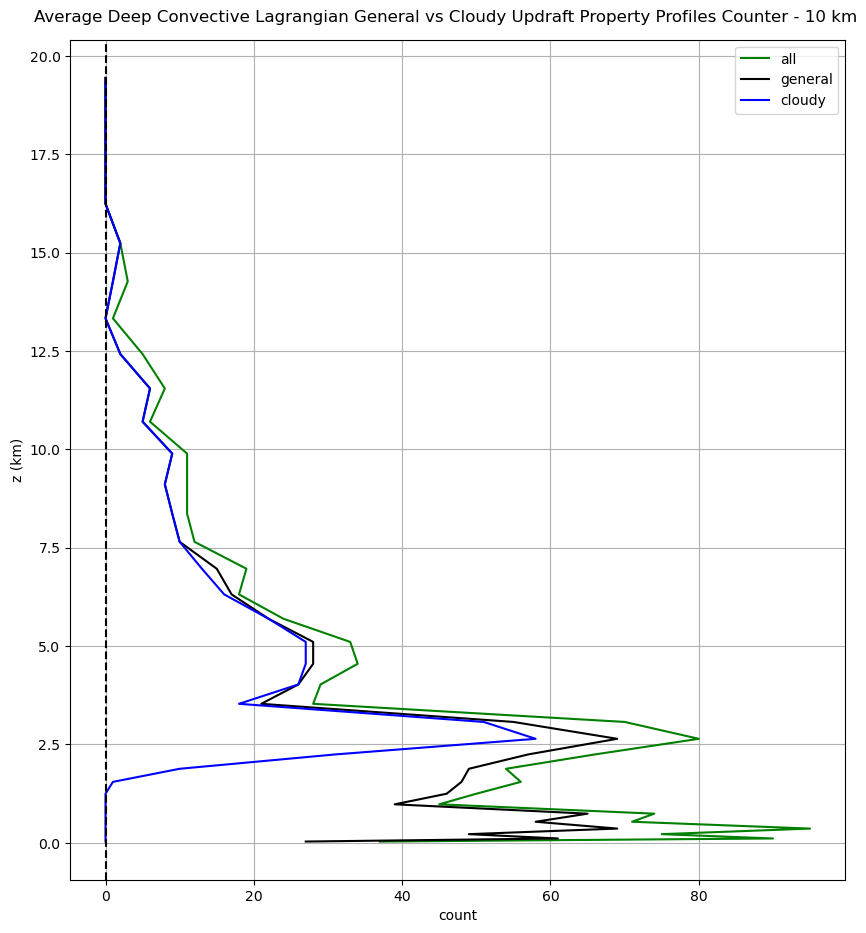

In [140]:
#Counter

# Uses Plotting Function 
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
fig.suptitle(f"Average Deep Convective Lagrangian General vs Cloudy Updraft Property Profiles Counter - {convectivelevel} km")
axis=axs
fig.subplots_adjust(top=0.95)

types=['all','general','cloudy']
labels=['all','general','cloudy']
colors=['green','k','blue']
for type,label,color in zip(types,labels,colors):
    if type=='all':
        input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
    if type=='general':
        input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
    if type=='cloudy':
        input_file=dir+f'tracking_algorithms/plots/job_out/deep_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
    
     #globalize output
    globals()['profile_w'] = profile_w
    globals()['profile_qv'] = profile_qv
    globals()['profile_qc'] = profile_qc
    globals()['profile_qi'] = profile_qi
    globals()['profile_th'] = profile_th


    
    profile=globals()[f'profile_w']
    # profile=profile[np.where(profile[:,1]!=0)]
    # profile[np.where(profile[:,1]==0)]=np.nan

    axis.plot(profile[:,1],profile[:,2],label=label,color=color)
    axis.set_xlabel('count');axis.set_ylabel('z (km)')

    if axis==axis:
        axis.legend();

axis.axvline(color='k',linestyle='dashed')
axis.grid()
#saving figure
fig.savefig(dir+f'tracking_algorithms/plots/deep_profiles_{convectivelevel}km_counter_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"

In [ ]:
#######################################################################################################################################
#Lagrangian Tracking for Tracked Shallow Convective Parcels

In [1]:
#Shallow Convective Parcels Profile
##### viewing tracking algorithm results
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import h5py

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [20]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
############################################################
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def threshold(zthresh):
    out_nz=placeholder.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz, extendrange
    # print(out_nz)
##############################################################

# convectivelevel=3 #3km
convectivelevel=4 #4km
[out_nz,extendrange]=threshold(convectivelevel)

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 

In [21]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh
    
# def grid_location(x,y,z): #faster
#     #finding xf and yf
#     ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
#     xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
#     dy=np.round(dy);dx=np.round(dx)

#     #digitizing
#     zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
#     if which_zh.ndim==0:
#         which_zh=np.array([which_zh])
#     which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
#     which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

#     #fixing boundaries
#     which_zh[np.where(which_zh==len(data['zh']))]-=1
#     which_yh[np.where(which_yh==len(data['yh']))]-=1
#     which_xh[np.where(which_xh==len(data['xh']))]-=1
#     return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for shallow parcel locations
######################################################

#Setting up run for shallow convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


shallow_t,shallow_z,shallow_y,shallow_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    shallow_t.extend(ranges[R])
    shallow_z.extend(which_z[tup])
    shallow_y.extend(which_y[tup])
    shallow_x.extend(which_x[tup])
shallow_t=np.array(shallow_t);shallow_z=np.array(shallow_z);shallow_y=np.array(shallow_y);shallow_x=np.array(shallow_x)
position=(shallow_t, shallow_z, shallow_y, shallow_x)
print('done')

running for total of 9717 elements
done


In [22]:
#Shallow Parcels Lagrangian Parcels Profile (OPTIMIZED) 

if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    print('done loading')
    emptylike=True


types=['general','cloudy','all']
vars=['w','qv','qc','qi','th','buoyancy']
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    global w_thresh
    w_thresh=1 #m/s
    qcqi_thresh=1e-6 #kg/kg
    all_thresh=-1e6
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        if var=='qv':
            lagrangian_var=qv_data[position]
        if var=='qc':
            lagrangian_var=qc_plus_qi[position] #data stored for qc is actually qc+qi
        if var=='qi':
            lagrangian_var=qi_data[position]
        if var=='th':
            lagrangian_var=th_data[position]
        if var=='buoyancy':
            lagrangian_var=buoyancy_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='general':
            masked_var=lagrangian_var[np.where(lagrangian_w>=w_thresh)]
            masked_z=shallow_z.flatten()[np.where(lagrangian_w>=w_thresh)]
        elif type=='cloudy':
            masked_var=lagrangian_var[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
            masked_z=shallow_z.flatten()[np.where((lagrangian_w>=w_thresh)&(lagrangian_qcplusqi>=qcqi_thresh))]
        elif type=='all':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=shallow_z.flatten()[np.where(lagrangian_w>=all_thresh)]
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='all':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
    if type=='general':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
    if type=='cloudy':
        output_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
        f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
    print('done')

type general
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done
type cloudy
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done
type all
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done


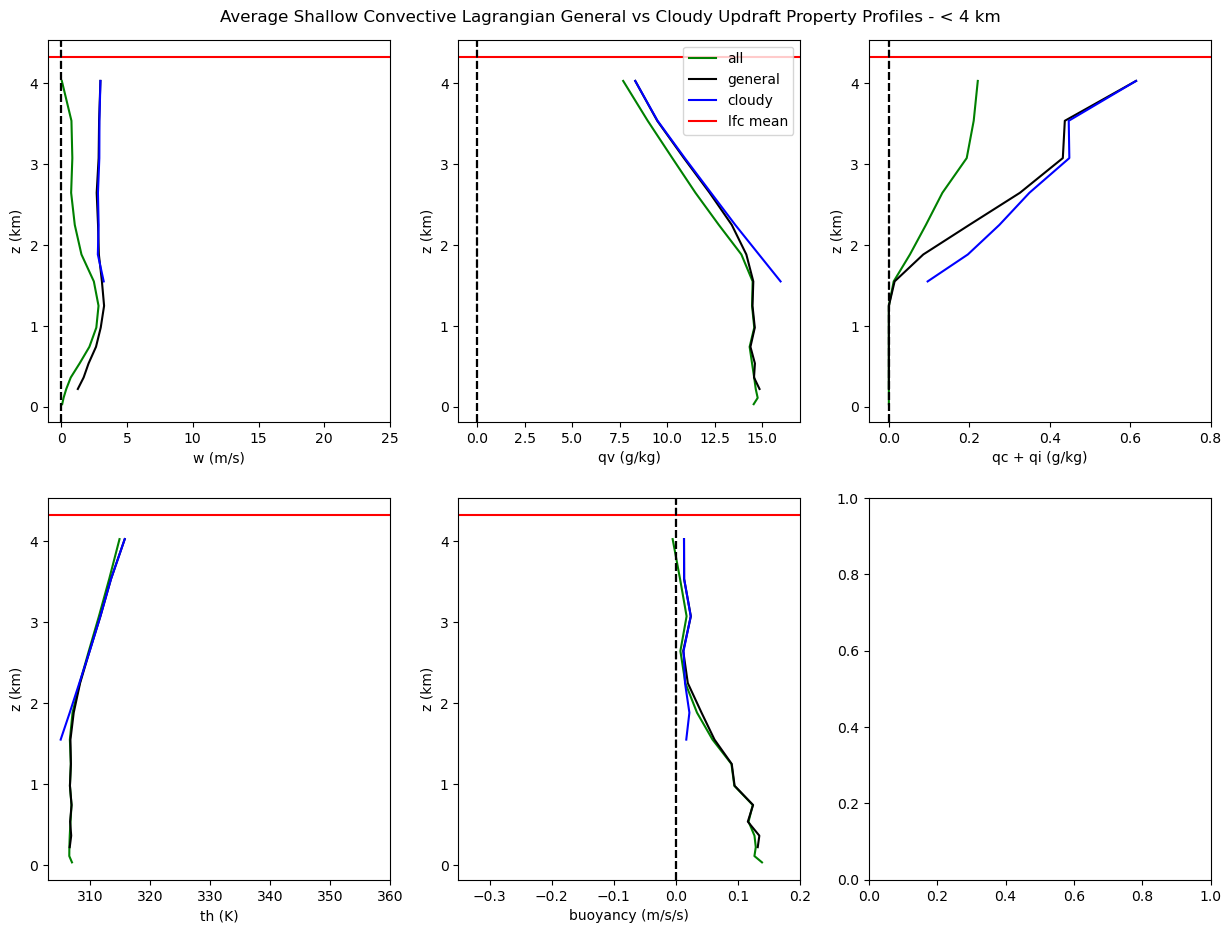

In [31]:
#Plotting for shallow tracked parcels 

w_thresh=1
convectivelevel=4

#last tracked time
zs=[]
for R in np.arange(len(out_nz)):
    z=parcel['z'].isel(xh=out_nz[:,0][R],time=out_nz[:,5][R]).values/1000
    zs.append(z)
avg_lfc=np.mean(zs)
max_lfc=np.max(zs)


# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average Shallow Convective Lagrangian General vs Cloudy Updraft Property Profiles - < {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
axises=[ax1,ax2,ax3,ax4,ax5,ax6]
fig.subplots_adjust(top=0.95)


#lfc
lfc_tmean=data['lfc'].mean(dim='time')/1000


vars=['w','qv','qc','th','buoyancy']
xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
for var,xlabel,axis in zip(vars,xlabels,axises):
    types=['all','general','cloudy']
    labels=['all','general','cloudy']
    colors=['green','k','blue']
    for type,label,color in zip(types,labels,colors):
        if type=='all':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
        if type=='general':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
        if type=='cloudy':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
        with h5py.File(input_file, 'r') as f:
            profile_w = np.array(f['profile_w'])
            profile_qv = np.array(f['profile_qv'])
            profile_qc = np.array(f['profile_qc'])
            profile_qi = np.array(f['profile_qi'])
            profile_th = np.array(f['profile_th'])
            profile_buoyancy = np.array(f['profile_buoyancy'])
        
         #globalize output
        globals()['profile_w'] = profile_w
        globals()['profile_qv'] = profile_qv
        globals()['profile_qc'] = profile_qc
        globals()['profile_qi'] = profile_qi
        globals()['profile_th'] = profile_th
        globals()['profile_buoyancy'] = profile_buoyancy

        #adding qc and qi profile together
        profile_qc[:,0]+=profile_qi[:,0] 
        profile_qc[:,1]+=profile_qi[:,1] 

        #converting kg/kg to g/kg
        profile_qv[:,0]*=1000
        profile_qc[:,0]*=1000
        
        #Produced averaged profiles for plotting
        def averaged_profiles(profile): 
            out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
            out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
            return out_var
        
        profile=averaged_profiles(globals()[f'profile_{var}'])
        yticks = np.arange(0, profile[:,1].max()+1, 1)
        axis.set_yticks(yticks)
    
        axis.plot(profile[:,0],profile[:,1],label=label,color=color)
        axis.set_xlabel(xlabel);axis.set_ylabel('z (km)')

        if axis==ax1:
            axis.set_xlim(-1,25)
        if axis==ax2:
            axis.set_xlim(-1,17)
        if axis==ax3:
            axis.set_xlim(-0.05,0.8)
        if axis==ax4:
            axis.set_xlim(303,360)
        if axis==ax5:
            axis.set_xlim(-0.35,0.2)      

        if type=='cloudy':
            axis.axhline(avg_lfc,color='red',linestyle='solid',label='lfc mean')
            # axis.axhline(max_lfc,color='red',linestyle='solid',label='lfc max')
        if var!='th':
            axis.axvline(0,linestyle='dashed',color='k')
        if axis==ax2:
            axis.legend(loc='upper right');

#saving figure
fig.savefig(dir+f'tracking_algorithms/plots/shallow_profiles_{convectivelevel}km_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"

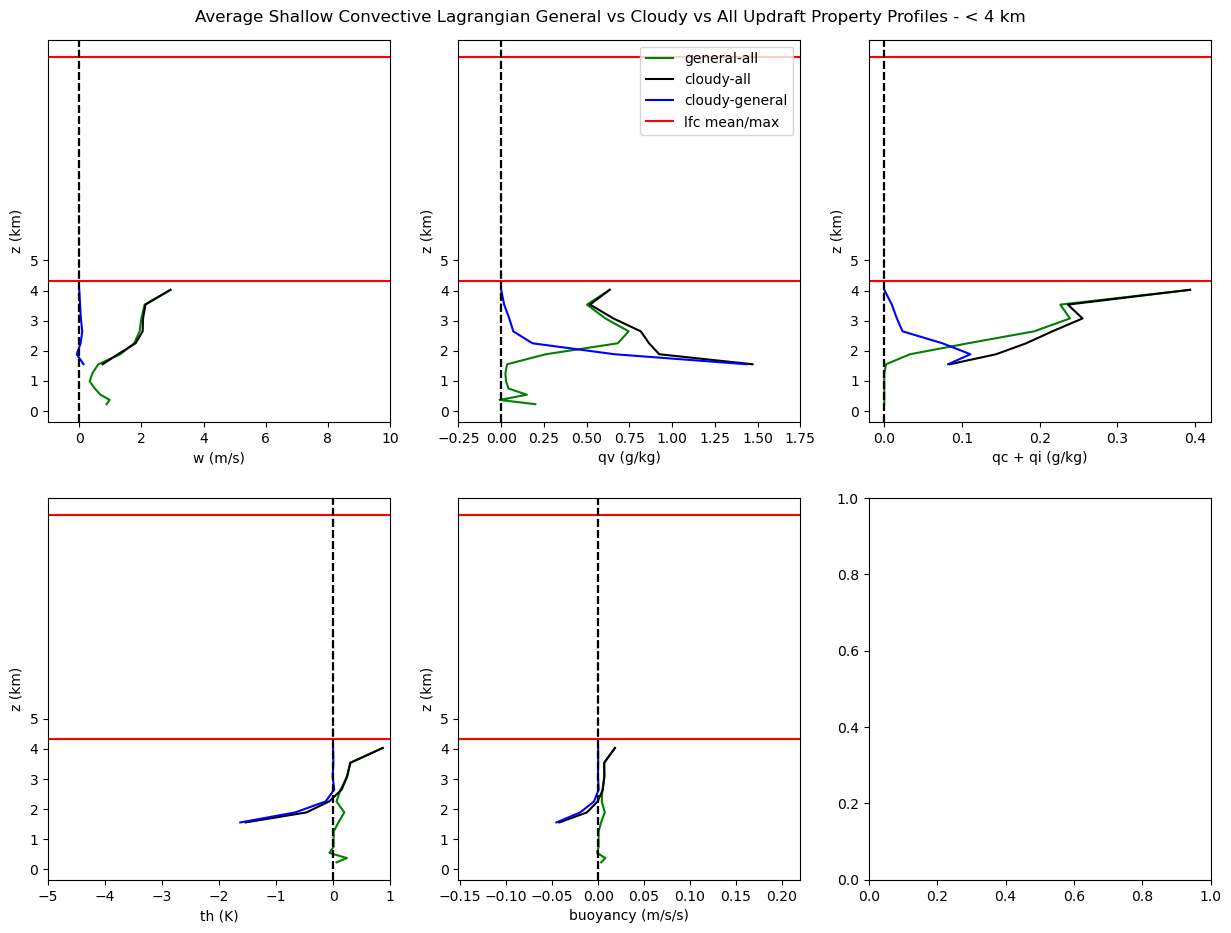

In [39]:
#DIFFERENCE PLOT
#general - all
#cloudy - all 
#cloudy - general

w_thresh=1
convectivelevel=4

#use for tracked parcels

#last tracked time
zs=[]
for R in np.arange(len(out_nz)):
    z=parcel['z'].isel(xh=out_nz[:,0][R],time=out_nz[:,5][R]).values/1000
    zs.append(z)
avg_lfc=np.mean(zs)
max_lfc=np.max(zs)


# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average Shallow Convective Lagrangian General vs Cloudy vs All Updraft Property Profiles - < {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
axises=[ax1,ax2,ax3,ax4,ax5,ax6]
fig.subplots_adjust(top=0.95)


#lfc
lfc_tmean=data['lfc'].mean(dim='time')/1000

#Produced averaged profiles for plotting
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

vars=['w','qv','qc','th','buoyancy']
xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
for var,xlabel,axis in zip(vars,xlabels,axises):
    types=['general-all','cloudy-all','cloudy-general']
    labels=['general-all','cloudy-all','cloudy-general']
    colors=['green','k','blue']
    for type,label,color in zip(types,labels,colors):
        if type=='general-all':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])



            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 
            #globalize output
            globals()['one_profile_w'] = profile_w
            globals()['one_profile_qv'] = profile_qv
            globals()['one_profile_qc'] = profile_qc
            globals()['one_profile_qi'] = profile_qi
            globals()['one_profile_th'] = profile_th
            globals()['one_profile_buoyancy'] = profile_buoyancy
                

            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
                
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 
            #globalize output
            globals()['two_profile_w'] = profile_w
            globals()['two_profile_qv'] = profile_qv
            globals()['two_profile_qc'] = profile_qc
            globals()['two_profile_qi'] = profile_qi
            globals()['two_profile_th'] = profile_th
            globals()['two_profile_buoyancy'] = profile_buoyancy

            #averaging
            out_var_one=averaged_profiles(globals()[f'one_profile_{var}'])
            out_var_two=averaged_profiles(globals()[f'two_profile_{var}'])
    
            #masking out non matches
            second_col_one = out_var_one[:, 1]
            second_col_two = out_var_two[:, 1]
            mask_one = np.isin(second_col_one, second_col_two)
            mask_two = np.isin(second_col_two, second_col_one)
            out_var_one = out_var_one.copy()[mask_one]
            out_var_two = out_var_two.copy()[mask_two]

        if type=='cloudy-all':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 

            #globalize output
            globals()['one_profile_w'] = profile_w
            globals()['one_profile_qv'] = profile_qv
            globals()['one_profile_qc'] = profile_qc
            globals()['one_profile_qi'] = profile_qi
            globals()['one_profile_th'] = profile_th
            globals()['one_profile_buoyancy'] = profile_buoyancy

            
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_all_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 

            #globalize output
            globals()['two_profile_w'] = profile_w
            globals()['two_profile_qv'] = profile_qv
            globals()['two_profile_qc'] = profile_qc
            globals()['two_profile_qi'] = profile_qi
            globals()['two_profile_th'] = profile_th
            globals()['two_profile_buoyancy'] = profile_buoyancy

            #averaging
            out_var_one=averaged_profiles(globals()[f'one_profile_{var}'])
            out_var_two=averaged_profiles(globals()[f'two_profile_{var}'])
    
            #masking out non matches
            second_col_one = out_var_one[:, 1]
            second_col_two = out_var_two[:, 1]
            mask_one = np.isin(second_col_one, second_col_two)
            mask_two = np.isin(second_col_two, second_col_one)
            out_var_one = out_var_one.copy()[mask_one]
            out_var_two = out_var_two.copy()[mask_two]
        
        if type=='cloudy-general':
            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_cloudy_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 

            #globalize output
            globals()['one_profile_w'] = profile_w
            globals()['one_profile_qv'] = profile_qv
            globals()['one_profile_qc'] = profile_qc
            globals()['one_profile_qi'] = profile_qi
            globals()['one_profile_th'] = profile_th
            globals()['one_profile_buoyancy'] = profile_buoyancy

            input_file=dir+f'tracking_algorithms/plots/job_out/shallow_profile_{convectivelevel}km_general_wthresh{w_thresh}.h5'
            with h5py.File(input_file, 'r') as f:
                profile_w = np.array(f['profile_w'])
                profile_qv = np.array(f['profile_qv'])
                profile_qc = np.array(f['profile_qc'])
                profile_qi = np.array(f['profile_qi'])
                profile_th = np.array(f['profile_th'])
                profile_buoyancy = np.array(f['profile_buoyancy'])
            #adding qc and qi profile together
            profile_qc[:,0]+=profile_qi[:,0] 
            profile_qc[:,1]+=profile_qi[:,1] 
        
            #globalize output
            globals()['two_profile_w'] = profile_w
            globals()['two_profile_qv'] = profile_qv
            globals()['two_profile_qc'] = profile_qc
            globals()['two_profile_qi'] = profile_qi
            globals()['two_profile_th'] = profile_th
            globals()['two_profile_buoyancy'] = profile_buoyancy

            #averaging
            out_var_one=averaged_profiles(globals()[f'one_profile_{var}'])
            out_var_two=averaged_profiles(globals()[f'two_profile_{var}'])
    
            #masking out non matches
            second_col_one = out_var_one[:, 1]
            second_col_two = out_var_two[:, 1]
            mask_one = np.isin(second_col_one, second_col_two)
            mask_two = np.isin(second_col_two, second_col_one)
            out_var_one = out_var_one.copy()[mask_one]
            out_var_two = out_var_two.copy()[mask_two]



        #kg/kg to g/kg
        if var in ['qv','qc']:
            out_var_one[:,0]*=1000
            out_var_two[:,0]*=1000
        axis.plot(out_var_one[:,0]-out_var_two[:,0],out_var_one[:,1],label=label,color=color)
        axis.set_xlabel(xlabel);axis.set_ylabel('z (km)')

        

        if type=='cloudy-general':
            axis.axhline(avg_lfc,color='red',linestyle='solid')
            axis.axhline(max_lfc,color='red',linestyle='solid',label='lfc mean/max')
     
        axis.axvline(0,linestyle='dashed',color='k')
        if axis==ax2:
            axis.legend(loc='upper right');
        yticks = np.arange(0, out_var_two[:,1].max()+1, 1)
        axis.set_yticks(yticks)
        
        if axis==ax1:
            axis.set_xlim(-1,10)
        if axis==ax2:
            axis.set_xlim(-0.25,1.75)
        if axis==ax3:
            axis.set_xlim(-0.02,0.42)
        if axis==ax4:
            axis.set_xlim(-5,1)
        if axis==ax5:
            axis.set_xlim(-0.152,0.22)  
    

#saving figure
fig.savefig(dir+f'tracking_algorithms/plots/shallow_profiles_{convectivelevel}km_diff_wthresh{w_thresh}.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"

In [ ]:
#######################################################################################################################################
#Lagrangian Tracking for Tracked Convective Parcels
#FROM CL VS non-CL

In [2]:
#Convective Parcels Profile
##### viewing tracking algorithm results
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import h5py

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [12]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
############################################################
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 SBZ parcels and 1717 forgotten parcels


In [44]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for CL parcel locations
######################################################

#Setting up run for CL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


CL_t,CL_z,CL_y,CL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    CL_t.extend(ranges[R])
    CL_z.extend(which_z[tup])
    CL_y.extend(which_y[tup])
    CL_x.extend(which_x[tup])
CL_t=np.array(CL_t);CL_z=np.array(CL_z);CL_y=np.array(CL_y);CL_x=np.array(CL_x)
CLposition=(CL_t, CL_z, CL_y, CL_x)
print('done')

#####################################################################################

#Makes np.where style mask for nonCL parcel locations
######################################################
out_nz=save_nz.copy() #out_nz is actually save_nz for code below

#Setting up run for nonCL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


nonCL_t,nonCL_z,nonCL_y,nonCL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    nonCL_t.extend(ranges[R])
    nonCL_z.extend(which_z[tup])
    nonCL_y.extend(which_y[tup])
    nonCL_x.extend(which_x[tup])
nonCL_t=np.array(nonCL_t);nonCL_z=np.array(nonCL_z);nonCL_y=np.array(nonCL_y);nonCL_x=np.array(nonCL_x)
nonCLposition=(nonCL_t, nonCL_z, nonCL_y, nonCL_x)
print('done')

running for total of 17364 elements
done
running for total of 14509 elements
done


In [46]:
#ALL Parcels Lagrangian Parcels Profile (OPTIMIZED) 

if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    print('done loading')
    emptylike=True


types=['CL','nonCL']
vars=['w','qv','qc','qi','th','buoyancy']
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    all_thresh=-1e6
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        elif var=='qv':
            lagrangian_var=qv_data[position]
        elif var=='qc':
            lagrangian_var=qc_plus_qi[position] 
        elif var=='qi':
            lagrangian_var=qi_data[position]
        elif var=='th':
            lagrangian_var=th_data[position]
        elif var=='buoyancy':
            lagrangian_var=buoyancy_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
            
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_ALL_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_ALL_profile.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
        f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
    print('done')

type CL
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done
type nonCL
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done


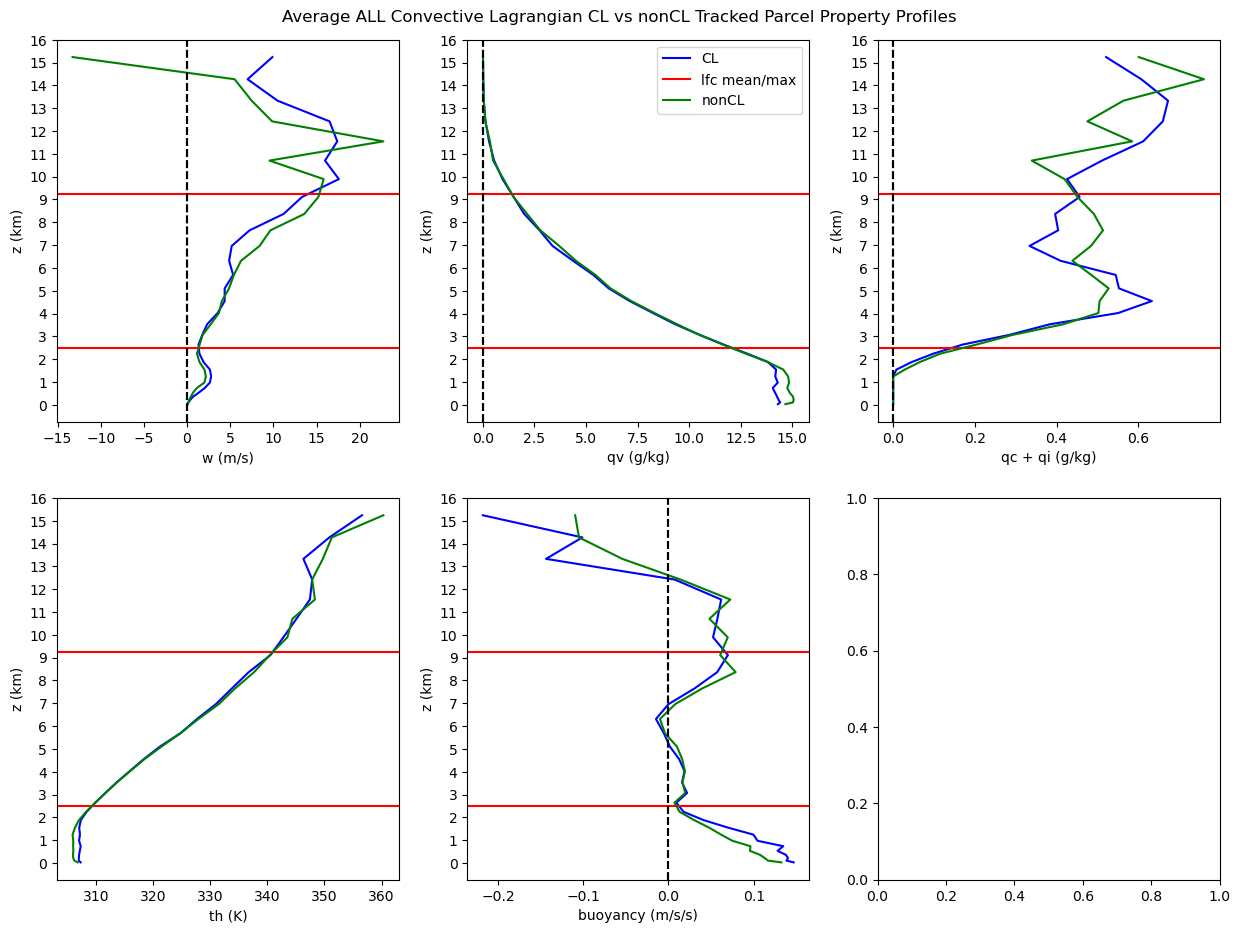

In [13]:
#Plotting for CL vs nonCL tracked parcels 

#ALL

#last tracked time
zs=[]
for R in np.arange(len(out_nz)):
    z=parcel['z'].isel(xh=out_nz[:,0][R],time=out_nz[:,5][R]).values/1000
    zs.append(z)
avg_lfc=np.mean(zs)
max_lfc=np.max(zs)


# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average ALL Convective Lagrangian CL vs nonCL Tracked Parcel Property Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
axises=[ax1,ax2,ax3,ax4,ax5,ax6]
fig.subplots_adjust(top=0.95)


#lfc
lfc_tmean=data['lfc'].mean(dim='time')/1000

vars=['w','qv','qc','th','buoyancy']
xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
for var,xlabel,axis in zip(vars,xlabels,axises):
    types=['CL','nonCL']
    labels=['CL','nonCL']
    colors=['blue','green']
    for type,label,color in zip(types,labels,colors):
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_ALL_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_ALL_profile.h5'
        with h5py.File(input_file, 'r') as f:
            profile_w = np.array(f['profile_w'])
            profile_qv = np.array(f['profile_qv'])
            profile_qc = np.array(f['profile_qc'])
            profile_qi = np.array(f['profile_qi'])
            profile_th = np.array(f['profile_th'])
            profile_buoyancy = np.array(f['profile_buoyancy'])
        
        #globalize output
        globals()['profile_w'] = profile_w
        globals()['profile_qv'] = profile_qv
        globals()['profile_qc'] = profile_qc
        globals()['profile_qi'] = profile_qi
        globals()['profile_th'] = profile_th
        globals()['profile_buoyancy'] = profile_buoyancy

        #adding qc and qi profile together
        profile_qc[:,0]+=profile_qi[:,0] 
        profile_qc[:,1]+=profile_qi[:,1] 

        #converting kg/kg to g/kg
        profile_qv[:,0]*=1000
        profile_qc[:,0]*=1000
        
        #Produced averaged profiles for plotting
        def averaged_profiles(profile): 
            out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
            out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
            return out_var
        
        profile=averaged_profiles(globals()[f'profile_{var}'])
        yticks = np.arange(0, profile[:,1].max()+1, 1)
        axis.set_yticks(yticks)
    
        axis.plot(profile[:,0],profile[:,1],label=label,color=color)
        axis.set_xlabel(xlabel);axis.set_ylabel('z (km)')

        if type=='CL':
            axis.axhline(avg_lfc,color='red',linestyle='solid')
            axis.axhline(max_lfc,color='red',linestyle='solid',label='lfc mean/max')
        if var!='th':
            axis.axvline(0,linestyle='dashed',color='k')
        if axis==ax2:
            axis.legend(loc='upper right');

#saving figure
fig.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_ALL_profiles.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"

In [ ]:
############################
# DEEP

In [39]:
#Convective Parcels Profile
##### viewing tracking algorithm results
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import h5py

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [9]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 

###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder1=out_nz.copy(); run=True
placeholder2=save_nz.copy(); run=True
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def threshold_out(zthresh):
    out_nz=placeholder1.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh):
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz, extendrange
    # print(out_nz)
##############################################################
def threshold_save(zthresh):
    save_nz=placeholder2.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(save_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(save_nz[ind,5],save_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=save_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh):
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    save_nz=save_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(save_nz)} leftover parcels')
    return save_nz, extendrange
    # print(save_nz)
##############################################################

convectivelevel=6 #6km
[out_nz,extendrange]=threshold_out(convectivelevel)
[save_nz,extendrange]=threshold_save(convectivelevel)

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} non-SBZ parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
list of first 10 SBZ parcels
[[452 334 53 0.1520338897705078 43 48]
 [704 374 63 0.24067965698242189 57 62]
 [885 300 10 0.11673685455322266 59 65]
 [1022 37

In [41]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for CL parcel locations
######################################################

#Setting up run for CL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


CL_t,CL_z,CL_y,CL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    CL_t.extend(ranges[R])
    CL_z.extend(which_z[tup])
    CL_y.extend(which_y[tup])
    CL_x.extend(which_x[tup])
CL_t=np.array(CL_t);CL_z=np.array(CL_z);CL_y=np.array(CL_y);CL_x=np.array(CL_x)
CLposition=(CL_t, CL_z, CL_y, CL_x)
print('done')

#####################################################################################

#Makes np.where style mask for nonCL parcel locations
######################################################
out_nz=save_nz.copy() #out_nz is actually save_nz for code below

#Setting up run for nonCL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


nonCL_t,nonCL_z,nonCL_y,nonCL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    nonCL_t.extend(ranges[R])
    nonCL_z.extend(which_z[tup])
    nonCL_y.extend(which_y[tup])
    nonCL_x.extend(which_x[tup])
nonCL_t=np.array(nonCL_t);nonCL_z=np.array(nonCL_z);nonCL_y=np.array(nonCL_y);nonCL_x=np.array(nonCL_x)
nonCLposition=(nonCL_t, nonCL_z, nonCL_y, nonCL_x)
print('done')

running for total of 3118 elements
done
running for total of 2672 elements
done


In [42]:
#DEEP Parcels Lagrangian Parcels Profile (OPTIMIZED) 

if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    print('done loading')
    emptylike=True


types=['CL','nonCL']
vars=['w','qv','qc','qi','th','buoyancy']
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    all_thresh=-1e6
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        elif var=='qv':
            lagrangian_var=qv_data[position]
        elif var=='qc':
            lagrangian_var=qc_plus_qi[position] 
        elif var=='qi':
            lagrangian_var=qi_data[position]
        elif var=='th':
            lagrangian_var=th_data[position]
        elif var=='buoyancy':
            lagrangian_var=buoyancy_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
            
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_DEEP_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_DEEP_profile.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
        f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
    print('done')

type CL
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done
type nonCL
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done


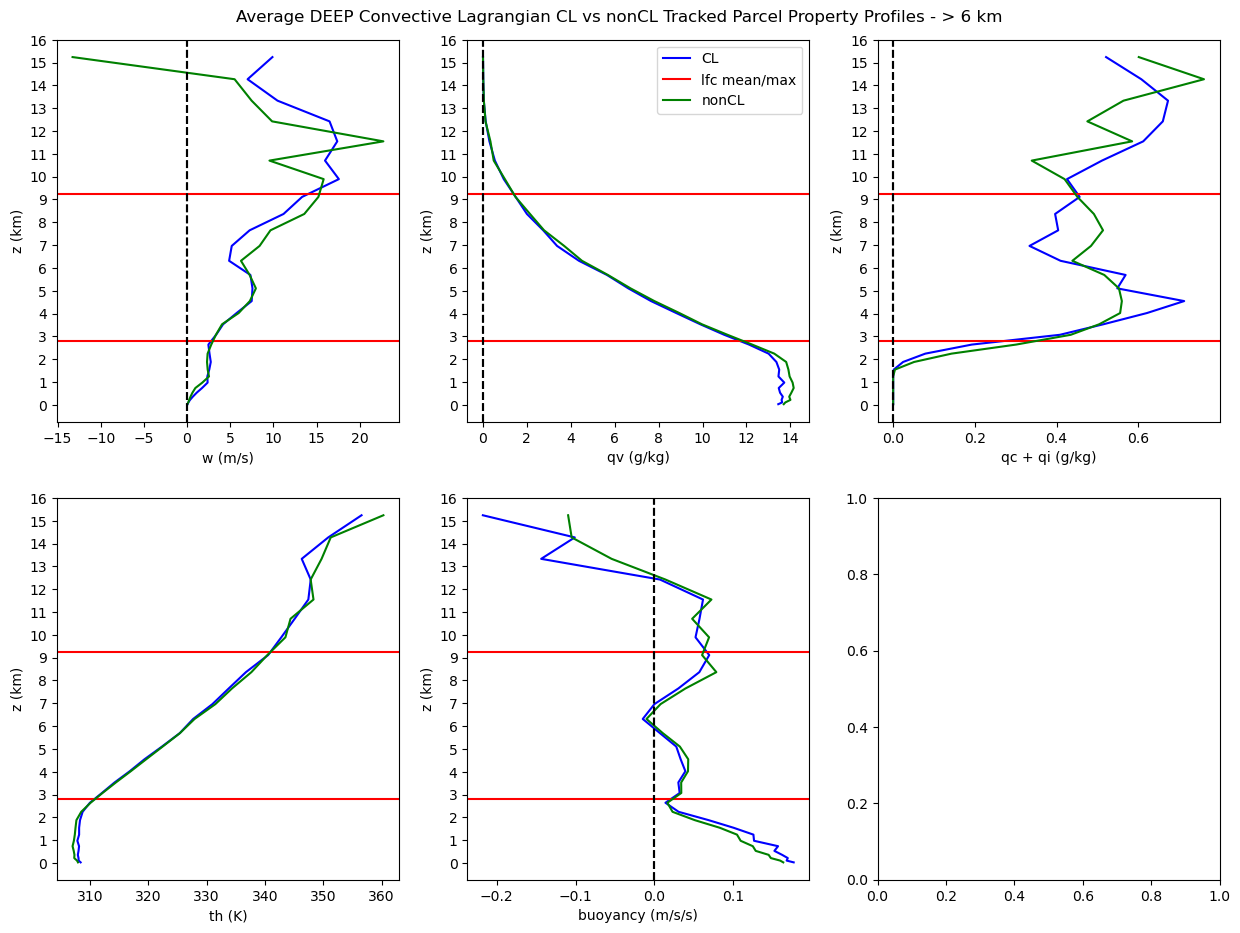

In [11]:
#Plotting for CL vs nonCL tracked parcels 

#last tracked time
zs=[]
for R in np.arange(len(out_nz)):
    z=parcel['z'].isel(xh=out_nz[:,0][R],time=out_nz[:,5][R]).values/1000
    zs.append(z)
avg_lfc=np.mean(zs)
max_lfc=np.max(zs)


# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average DEEP Convective Lagrangian CL vs nonCL Tracked Parcel Property Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
axises=[ax1,ax2,ax3,ax4,ax5,ax6]
fig.subplots_adjust(top=0.95)


#lfc
lfc_tmean=data['lfc'].mean(dim='time')/1000

vars=['w','qv','qc','th','buoyancy']
xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
for var,xlabel,axis in zip(vars,xlabels,axises):
    types=['CL','nonCL']
    labels=['CL','nonCL']
    colors=['blue','green']
    for type,label,color in zip(types,labels,colors):
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_DEEP_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_DEEP_profile.h5'
        with h5py.File(input_file, 'r') as f:
            profile_w = np.array(f['profile_w'])
            profile_qv = np.array(f['profile_qv'])
            profile_qc = np.array(f['profile_qc'])
            profile_qi = np.array(f['profile_qi'])
            profile_th = np.array(f['profile_th'])
            profile_buoyancy = np.array(f['profile_buoyancy'])
        
        #globalize output
        globals()['profile_w'] = profile_w
        globals()['profile_qv'] = profile_qv
        globals()['profile_qc'] = profile_qc
        globals()['profile_qi'] = profile_qi
        globals()['profile_th'] = profile_th
        globals()['profile_buoyancy'] = profile_buoyancy

        #adding qc and qi profile together
        profile_qc[:,0]+=profile_qi[:,0] 
        profile_qc[:,1]+=profile_qi[:,1] 

        #converting kg/kg to g/kg
        profile_qv[:,0]*=1000
        profile_qc[:,0]*=1000
        
        #Produced averaged profiles for plotting
        def averaged_profiles(profile): 
            out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
            out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
            return out_var
        
        profile=averaged_profiles(globals()[f'profile_{var}'])
        yticks = np.arange(0, profile[:,1].max()+1, 1)
        axis.set_yticks(yticks)
    
        axis.plot(profile[:,0],profile[:,1],label=label,color=color)
        axis.set_xlabel(xlabel);axis.set_ylabel('z (km)')

        if type=='CL':
            axis.axhline(avg_lfc,color='red',linestyle='solid')
            axis.axhline(max_lfc,color='red',linestyle='solid',label='lfc mean/max')
        if var!='th':
            axis.axvline(0,linestyle='dashed',color='k')
        if axis==ax2:
            axis.legend(loc='upper right');

#saving figure
fig.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_DEEP_profiles.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"

In [ ]:
####################
#SHALLOW

In [32]:
#Convective Parcels Profile
##### viewing tracking algorithm results
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import h5py

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [19]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 

###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder1=out_nz.copy(); run=True
placeholder2=save_nz.copy(); run=True
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def threshold_out(zthresh):
    out_nz=placeholder1.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #<shallow, >deep
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz, extendrange
    # print(out_nz)
##############################################################
def threshold_save(zthresh):
    save_nz=placeholder2.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(save_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(save_nz[ind,5],save_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=save_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #<shallow, >deep
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    save_nz=save_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(save_nz)} leftover parcels')
    return save_nz, extendrange
    # print(save_nz)
##############################################################

convectivelevel=4 #4km
[out_nz,extendrange]=threshold_out(convectivelevel)
[save_nz,extendrange]=threshold_save(convectivelevel)

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} non-SBZ parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 

In [34]:
def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh

x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

#Makes np.where style mask for CL parcel locations
######################################################

#Setting up run for CL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


CL_t,CL_z,CL_y,CL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    CL_t.extend(ranges[R])
    CL_z.extend(which_z[tup])
    CL_y.extend(which_y[tup])
    CL_x.extend(which_x[tup])
CL_t=np.array(CL_t);CL_z=np.array(CL_z);CL_y=np.array(CL_y);CL_x=np.array(CL_x)
CLposition=(CL_t, CL_z, CL_y, CL_x)
print('done')

#####################################################################################

#Makes np.where style mask for nonCL parcel locations
######################################################
out_nz=save_nz.copy() #out_nz is actually save_nz for code below

#Setting up run for nonCL convective parcels
# np.arange(Np)==>out_nz[:,0]
# np.arange(Nt)==>out_nz[:,4]
col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
col5 = out_nz[:, 5].astype(int) + 2 #add another 10 minutes to each trajectory
ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
indexes = out_nz[:,0]
indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
totalelements=sum(len(arr) for arr in ranges)
print(f'running for total of {totalelements} elements')


nonCL_t,nonCL_z,nonCL_y,nonCL_x=[],[],[],[]
for R in np.arange(len(ranges)):
    tup=(ranges[R],indexranges[R])
    nonCL_t.extend(ranges[R])
    nonCL_z.extend(which_z[tup])
    nonCL_y.extend(which_y[tup])
    nonCL_x.extend(which_x[tup])
nonCL_t=np.array(nonCL_t);nonCL_z=np.array(nonCL_z);nonCL_y=np.array(nonCL_y);nonCL_x=np.array(nonCL_x)
nonCLposition=(nonCL_t, nonCL_z, nonCL_y, nonCL_x)
print('done')

running for total of 9717 elements
done
running for total of 8915 elements
done


In [35]:
#SHALLOW Parcels Lagrangian Parcels Profile (OPTIMIZED) 

if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].data # get qc data
    print('done loading')
    emptylike=True


types=['CL','nonCL']
vars=['w','qv','qc','qi','th','buoyancy']
for type in types:
    print(f"type {type}")
    if type=='CL':
        position=CLposition
    elif type=='nonCL':
        position=nonCLposition

    # #creates profile storage and adds z column  
    all_thresh=-1e6
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # position=(which_t.flatten(), which_z.flatten(), which_y.values.flatten(), which_x.values.flatten())
    lagrangian_w=w_data[position]
    lagrangian_qcplusqi=qc_plus_qi[position]
    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            lagrangian_var=w_data[position]
        elif var=='qv':
            lagrangian_var=qv_data[position]
        elif var=='qc':
            lagrangian_var=qc_plus_qi[position] 
        elif var=='qi':
            lagrangian_var=qi_data[position]
        elif var=='th':
            lagrangian_var=th_data[position]
        elif var=='buoyancy':
            lagrangian_var=buoyancy_data[position]

              
        #if w_zdata greater than threshold, add to profile z column and add count
        if type=='CL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=CL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
        elif type=='nonCL':
            masked_var=lagrangian_var[np.where(lagrangian_w>=all_thresh)]
            masked_z=nonCL_z.flatten()[np.where(lagrangian_w>=all_thresh)]
            
            
        for count,(kh,value) in enumerate(zip(masked_z,masked_var)):
            # if np.mod(count,200)==0: print(f"{np.round(count*100/len(masked_z),1)}% done")
            globals()[f"profile_{var}"][kh,0]+=value #adds data to first column
            globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
    if type=='CL':
        output_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_SHALLOW_profile.h5'
    elif type=='nonCL':
        output_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_SHALLOW_profile.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
        f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
    print('done')

type CL
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done
type nonCL
variable w
variable qv
variable qc
variable qi
variable th
variable buoyancy
done


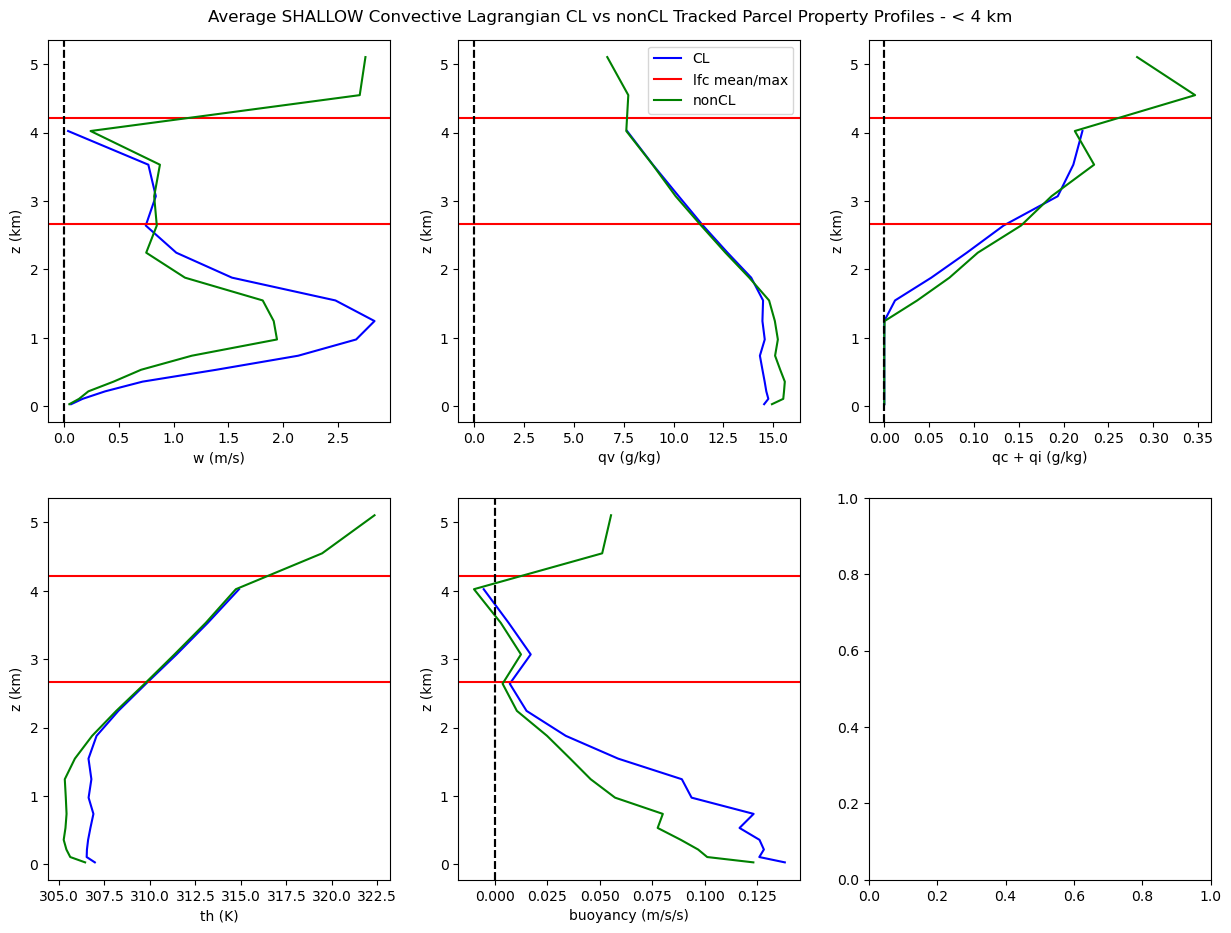

In [20]:
#Plotting for CL vs nonCL tracked parcels 

#last tracked time
zs=[]
for R in np.arange(len(out_nz)):
    z=parcel['z'].isel(xh=out_nz[:,0][R],time=out_nz[:,5][R]).values/1000
    zs.append(z)
avg_lfc=np.mean(zs)
max_lfc=np.max(zs)


# Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Average SHALLOW Convective Lagrangian CL vs nonCL Tracked Parcel Property Profiles - < {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
axises=[ax1,ax2,ax3,ax4,ax5,ax6]
fig.subplots_adjust(top=0.95)


#lfc
lfc_tmean=data['lfc'].mean(dim='time')/1000

vars=['w','qv','qc','th','buoyancy']
xlabels=['w (m/s)','qv (g/kg)','qc + qi (g/kg)','th (K)','buoyancy (m/s/s)']
for var,xlabel,axis in zip(vars,xlabels,axises):
    types=['CL','nonCL']
    labels=['CL','nonCL']
    colors=['blue','green']
    for type,label,color in zip(types,labels,colors):
        if type=='CL':
            input_file=dir+f'tracking_algorithms/plots/job_out/CL_lagrangian_SHALLOW_profile.h5'
        elif type=='nonCL':
            input_file=dir+f'tracking_algorithms/plots/job_out/nonCL_lagrangian_SHALLOW_profile.h5'
        with h5py.File(input_file, 'r') as f:
            profile_w = np.array(f['profile_w'])
            profile_qv = np.array(f['profile_qv'])
            profile_qc = np.array(f['profile_qc'])
            profile_qi = np.array(f['profile_qi'])
            profile_th = np.array(f['profile_th'])
            profile_buoyancy = np.array(f['profile_buoyancy'])
        
        #globalize output
        globals()['profile_w'] = profile_w
        globals()['profile_qv'] = profile_qv
        globals()['profile_qc'] = profile_qc
        globals()['profile_qi'] = profile_qi
        globals()['profile_th'] = profile_th
        globals()['profile_buoyancy'] = profile_buoyancy

        #adding qc and qi profile together
        profile_qc[:,0]+=profile_qi[:,0] 
        profile_qc[:,1]+=profile_qi[:,1] 

        #converting kg/kg to g/kg
        profile_qv[:,0]*=1000
        profile_qc[:,0]*=1000
        
        #Produced averaged profiles for plotting
        def averaged_profiles(profile): 
            out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
            out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
            return out_var
        
        profile=averaged_profiles(globals()[f'profile_{var}'])
        yticks = np.arange(0, profile[:,1].max()+1, 1)
        axis.set_yticks(yticks)
    
        axis.plot(profile[:,0],profile[:,1],label=label,color=color)
        axis.set_xlabel(xlabel);axis.set_ylabel('z (km)')

        if type=='CL':
            axis.axhline(avg_lfc,color='red',linestyle='solid')
            axis.axhline(max_lfc,color='red',linestyle='solid',label='lfc mean/max')
        if var!='th':
            axis.axvline(0,linestyle='dashed',color='k')
        if axis==ax2:
            axis.legend(loc='upper right');

#saving figure
fig.savefig(dir+f'tracking_algorithms/plots/CLvsnonCL_lagrangian_SHALLOW_profiles.jpg', bbox_inches='tight', dpi=300) # uncomment if "general updrafts"

In [ ]:
############
#TESTING

In [ ]:
# #TESTING OUTPUT OF OPTIMIZED LAGRANGIAN PROFILE CODE
# type=='general'
# if type=='general':
#     input_file = dir+'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_alljobs.h5'
# elif type=='cloudy':
#     input_file = dir+'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_alljobs.h5' 

# with h5py.File(input_file, 'r') as f:
#     profile_w = np.array(f['profile_w'])
#     profile_qv = np.array(f['profile_qv'])
#     profile_qc = np.array(f['profile_qc'])
#     profile_qi = np.array(f['profile_qi'])
#     profile_th = np.array(f['profile_th'])
#     profile_buoyancy = np.array(f['profile_buoyancy'])



# if type=='general':
#     input_file=dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_TEST.h5'
# if type=='cloudy':
#     input_file=dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_TEST.h5'

# with h5py.File(input_file, 'r') as f:
#     profile_w2 = np.array(f['profile_w'])
#     profile_qv2 = np.array(f['profile_qv'])
#     profile_qc2 = np.array(f['profile_qc'])
#     profile_qi2 = np.array(f['profile_qi'])
#     profile_th2 = np.array(f['profile_th'])
#     profile_buoyancy2 = np.array(f['profile_buoyancy'])

# def averaged_profiles(profile):
#     out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
#     out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
#     return out_var

# one=averaged_profiles(profile_buoyancy)
# two=averaged_profiles(profile_w2)
# # plt.plot(one[:,0],one[:,1])
# plt.plot(two[:,0],two[:,1])

# print(one[:,0]-two[:,0])

In [ ]:
# #All Parcels Lagrangian Parcels Profile (NOT OPTIMIZED)
# vars=['w','qv','qc','qi','th','buoyancy']
# types=['general','cloudy']
# for type in types:

#     # #creates profile storage and adds z column  
#     w_thresh=1 #m/s
#     qcqi_thresh=1e-6 #kg/kg
#     Nt=len(data['time'])
#     Nz=len(data['zh'])
#     Np=len(parcel['xh'])
    
#     #create profile array
#     for var in vars:
#         zhs=data['zh'].values
#         globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
#         globals()[f"profile_{var}"][:,2]=zhs

#     for t in np.arange(Nt):
#         # if t==1: break #TESTING***
#         for N in np.arange(Np):
#             # if N==100:break #TESTING***
#             if np.mod(N,100)==0: print(N)
#             kh=which_z[t,N]
#             jh=which_y[t,N]
#             ih=which_x[t,N]
                    
#             w_data=data['w'].isel(time=t).interp(zf=data['zh'])
#             w_data=w_data.isel(zh=kh,yh=jh,xh=ih).item()
#             var_data=w_data

#             qv_data=data['qv'].isel(time=t,zh=kh,yh=jh,xh=ih)
#             qc_data=data['qc'].isel(time=t,zh=kh,yh=jh,xh=ih)
#             qi_data=data['qi'].isel(time=t,zh=kh,yh=jh,xh=ih)
#             qcqi_data=qc_data+qi_data

#             th_data=data['th'].isel(time=t,zh=kh,yh=jh,xh=ih)
#             buoyancy_data=data['buoyancy'].isel(time=t,zh=kh,yh=jh,xh=ih)

#             #globalize variables
#             globals()['w_data'] = w_data
#             globals()['qv_data'] = qv_data
#             globals()['qc_data'] = qc_data
#             globals()['qi_data'] = qi_data
#             globals()['th_data'] = th_data
#             globals()['buoyancy_data'] = buoyancy_data
                  
#             #if w_zdata greater than threshold, add to profile z column and add count
#             if type=='general':
#                 if var_data>=w_thresh:
#                     for var in vars:
#                         globals()[f"profile_{var}"][kh,0]+=globals()[f"{var}_data"] #adds data to first column
#                         globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
#             if type=='cloudy':
#                 if (var_data>=w_thresh) & (qcqi_data>=qcqi_thresh):
#                     for var in vars:
#                         globals()[f"profile_{var}"][kh,0]+=globals()[f"{var}_data"] #adds data to first column
#                         globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
    
#     if type=='general':
#         output_file=dir+f'tracking_algorithms/plots/job_out/profile_{job_id}_general.h5'
#     if type=='cloudy':
#         output_file=dir+f'tracking_algorithms/plots/job_out/profile_{job_id}_cloudy.h5'
#     import h5py
#     with h5py.File(output_file, 'w') as f:
#         f.create_dataset('profile_w', data=profile_w, compression="gzip")
#         f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
#         f.create_dataset('profile_qc', data=profile_qc, compression="gzip")
#         f.create_dataset('profile_qi', data=profile_qi, compression="gzip")
#         f.create_dataset('profile_th', data=profile_th, compression="gzip")
#         f.create_dataset('profile_buoyancy', data=profile_buoyancy, compression="gzip")
#     print('done')

In [ ]:
# ############################################## (NOT OPTIMIZED)
# #Run after job_array

# #Adding all job_array profiles into a single profile
# dim='1km' 
# # dim='250m'

# for type in ["general","cloudy"]:
#     print(f'currently on type {type}')
    
#     import h5py
#     num_jobs=60
     
#     def output_profile(job_id):
    
#         if dim=='1km':
#             if type=='general':
#                 input_file = dir+f'tracking_algorithms/plots/job_out/profile_{job_id}_general.h5' #uncomment if "general updrafts"
#             elif type=='cloudy':
#                 input_file = dir+f'tracking_algorithms/plots/job_out/profile_{job_id}_cloudy.h5' #uncomment if "cloudy updrafts"
    
#         if dim=='250m':
#             if type=='general':
#                 input_file = dir+f'tracking_algorithms/plots/job_out/profile_{job_id}_general.h5' #uncomment if "general updrafts"
#             elif type=='cloudy':
#                 input_file = dir+f'tracking_algorithms/plots/job_out/profile_{job_id}_cloudy.h5' #uncomment if "cloudy updrafts"
        
#         with h5py.File(input_file, 'r') as f:
#             profile_w = np.array(f['profile_w'])
#             profile_qv = np.array(f['profile_qv'])
#             profile_qc = np.array(f['profile_qc'])
#             profile_qi = np.array(f['profile_qi'])
#             profile_th = np.array(f['profile_th'])
#             profile_buoyancy = np.array(f['profile_buoyancy'])
#         return profile_w,profile_qv,profile_qc,profile_qi,profile_th,profile_buoyancy
    
    
#     profile_w1,profile_qv1,profile_qc1,profile_qi1,profile_th1,profile_buoyancy1=output_profile(1)
#     for ind in np.arange(1+1,num_jobs+1):
#         profile_w2,profile_qv2,profile_qc2,profile_qi2,profile_th2,profile_buoyancy2=output_profile(ind)
        
#         profile_w1[:,0:2]+=profile_w2[:,0:2]
#         profile_qv1[:,0:2]+=profile_qv2[:,0:2]
#         profile_qc1[:,0:2]+=profile_qc2[:,0:2]
#         profile_qi1[:,0:2]+=profile_qi2[:,0:2]
#         profile_th1[:,0:2]+=profile_th2[:,0:2]
#         profile_buoyancy1[:,0:2]+=profile_buoyancy2[:,0:2]
    
#     if dim=='1km':
#         if type=='general':
#             output_file = dir+f'tracking_algorithms/plots/job_out/1km_general_lagrangian_profiles_alljobs.h5' #uncomment if "general updrafts"
#         elif type=='cloudy':
#             output_file = dir+f'tracking_algorithms/plots/job_out/1km_cloudy_lagrangian_profiles_alljobs.h5' #uncomment if "cloudy updrafts"
#     if dim=='250m':
#         if type=='general':
#             output_file = dir+f'tracking_algorithms/plots/job_out/250m_general_lagrangian_profiles_alljobs.h5' #uncomment if "general updrafts"
#         elif type=='cloudy':
#             output_file = dir+f'tracking_algorithms/plots/job_out/250m_cloudy_lagrangian_profiles_alljobs.h5' #uncomment if "cloudy updrafts"
    
#     with h5py.File(output_file, 'w') as f:
#         f.create_dataset('profile_w', data=profile_w1, compression="gzip")
#         f.create_dataset('profile_qv', data=profile_qv1, compression="gzip")
#         f.create_dataset('profile_qc', data=profile_qc1, compression="gzip")
#         f.create_dataset('profile_qi', data=profile_qi1, compression="gzip")
#         f.create_dataset('profile_th', data=profile_th1, compression="gzip")
#         f.create_dataset('profile_buoyancy', data=profile_buoyancy1, compression="gzip")